In [1]:
import sys
sys.path.insert(0, '/home/stargix/Desktop/uni/aprens/Lab8/APRNS-Lab-8/pytorch-generative')

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import optim
from torch.utils.data import Dataset, DataLoader
from torch.nn import functional as F
from torch.optim import lr_scheduler
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import train_test_split
from tqdm import tqdm
from apafib import load_MITBIH
import sys
from pytorch_generative import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

2025-12-10 17:22:38.742075: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-12-10 17:22:38.796839: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Usando dispositivo: cuda


In [3]:
# Load data with offline handling
import os
import pickle

# Try to load from cache first
cache_file = os.path.expanduser('~/.cache/apafib/mitbih_data.pkl')

try:
    if os.path.exists(cache_file):
        print("Loading data from local cache...")
        with open(cache_file, 'rb') as f:
            cache_data = pickle.load(f)
            data = cache_data['data']
        print("Data loaded from cache successfully!")
    else:
        print("Attempting to download data...")
        data = load_MITBIH()
        # Save to cache for future use
        os.makedirs(os.path.dirname(cache_file), exist_ok=True)
        with open(cache_file, 'wb') as f:
            pickle.dump({'data': data}, f)
        print("Data downloaded and cached successfully!")
except Exception as e:
    print(f"Error loading data: {e}")
    print("\n⚠️  Network error detected. Options:")
    print("1. Connect to internet and re-run this cell")
    print("2. Copy data from another notebook that already has it loaded")
    print("3. Use a saved pickle file if available")
    raise

X = data.iloc[:, :-1].values
y = data.iloc[:, -1].values

X_normal = X[y == 'Normal'] 

padding = np.zeros((X_normal.shape[0], 2))
X_padded = np.hstack((X_normal, padding))

print(f"Shape original: {X_normal.shape}, Shape con padding: {X_padded.shape}")

X_discretization, X_autoreg = train_test_split(X_padded, test_size=0.66, random_state=42)

Loading data from local cache...
Data loaded from cache successfully!
Shape original: (7263, 94), Shape con padding: (7263, 96)


In [4]:
# Define helper functions
def discretize_signals(signals, window_size, model):
    n_samples, length = signals.shape
    windows = signals.reshape(-1, window_size)
    tokens = model.predict(windows)
    return tokens.reshape(n_samples, -1)

def reconstruct_signals(tokens, window_size, model):
    centroids = model.means_
    n_samples, n_tokens = tokens.shape
    reconstructed = np.zeros((n_samples, n_tokens * window_size))
    
    for i in range(n_samples):
        seq = centroids[tokens[i]]
        reconstructed[i] = seq.flatten()
        
    return reconstructed

def generate_samples(model, n_samples, seq_len, vocab_size, window_size, gmm_model):
    model.eval()
    input_dim = seq_len * vocab_size
    conditioned_on = (torch.ones((n_samples, input_dim)) * -1).to(device)
    
    with torch.no_grad():
        samples_flat = model.sample(n_samples, conditioned_on=conditioned_on)
    
    samples_reshaped = samples_flat.view(n_samples, seq_len, vocab_size)
    tokens = torch.argmax(samples_reshaped, dim=2).cpu().numpy()
    signals = reconstruct_signals(tokens, window_size, gmm_model)
    return signals

class ECGTokenDataset(Dataset):
    def __init__(self, token_data, vocab_size):
        self.data = token_data
        self.vocab_size = vocab_size

    def __getitem__(self, index):
        tokens = torch.tensor(self.data[index], dtype=torch.long)
        x_onehot = F.one_hot(tokens, num_classes=self.vocab_size).float()
        return x_onehot.view(-1) 

    def __len__(self):
        return len(self.data)


CONFIGURACIÓN 1/6
WINDOW_SIZE: 6, VOCAB_SIZE: 128, HIDDEN_DIMS: [256]



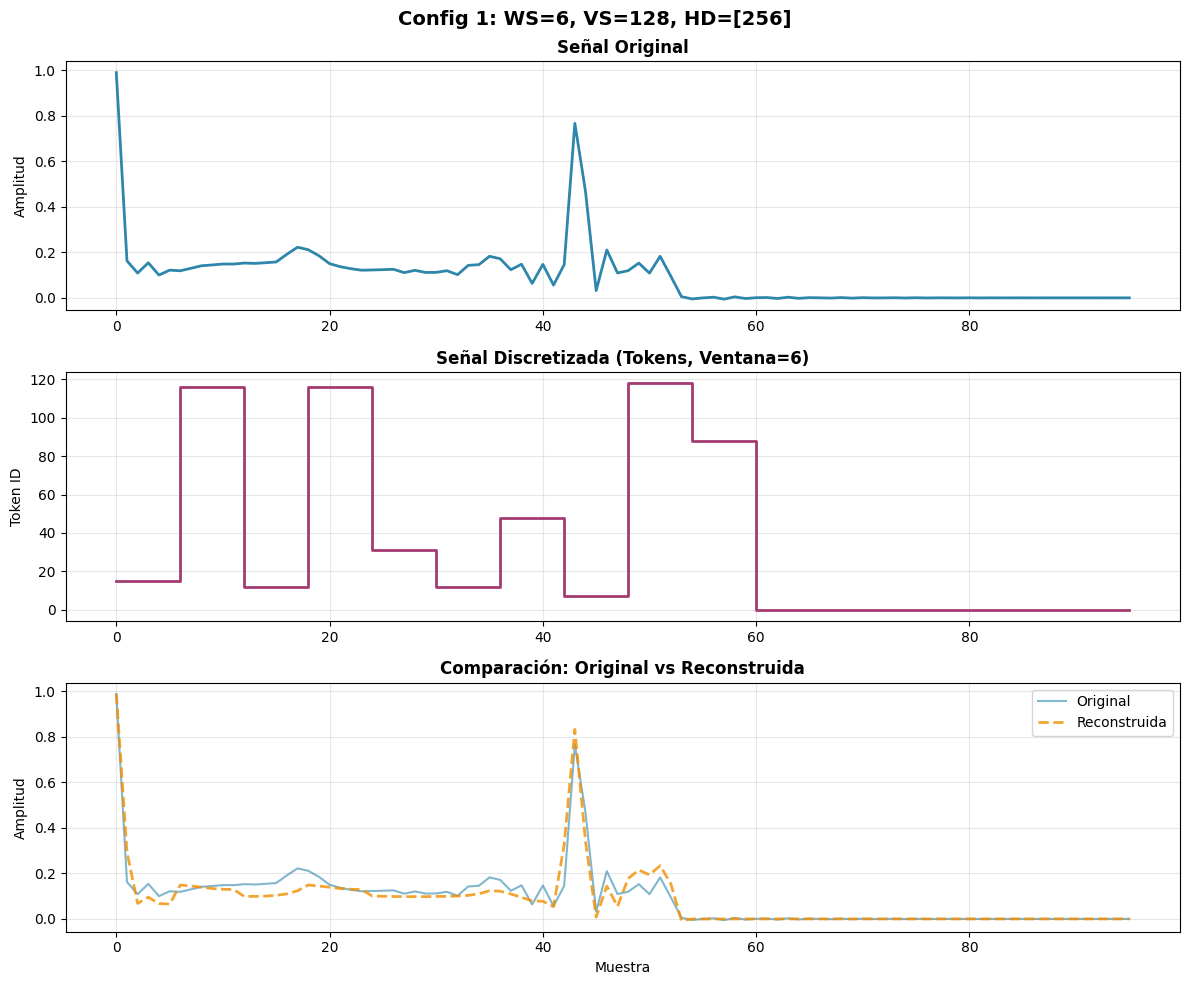


CONFIGURACIÓN 2/6
WINDOW_SIZE: 4, VOCAB_SIZE: 128, HIDDEN_DIMS: [256]



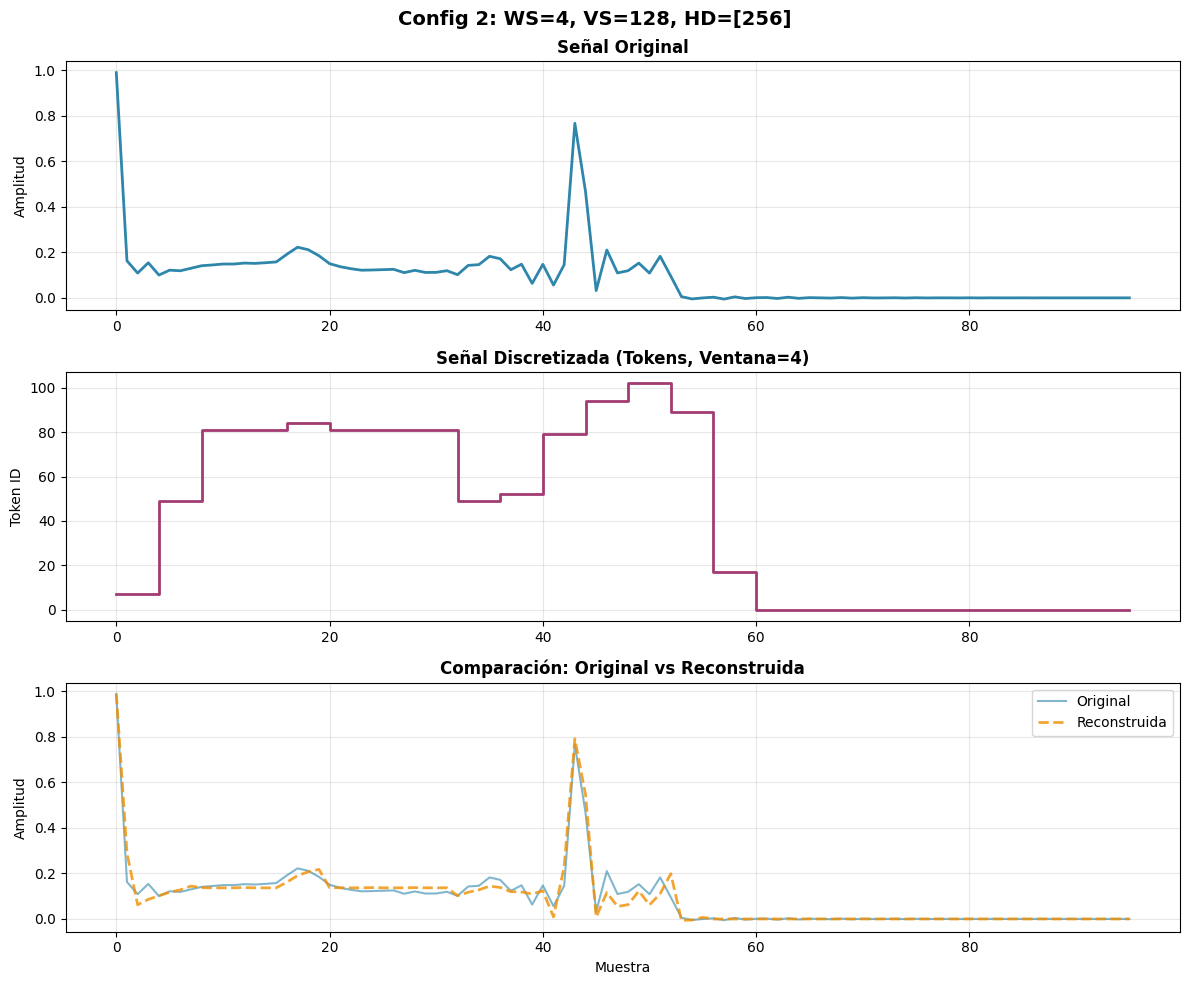


CONFIGURACIÓN 3/6
WINDOW_SIZE: 6, VOCAB_SIZE: 64, HIDDEN_DIMS: [256]



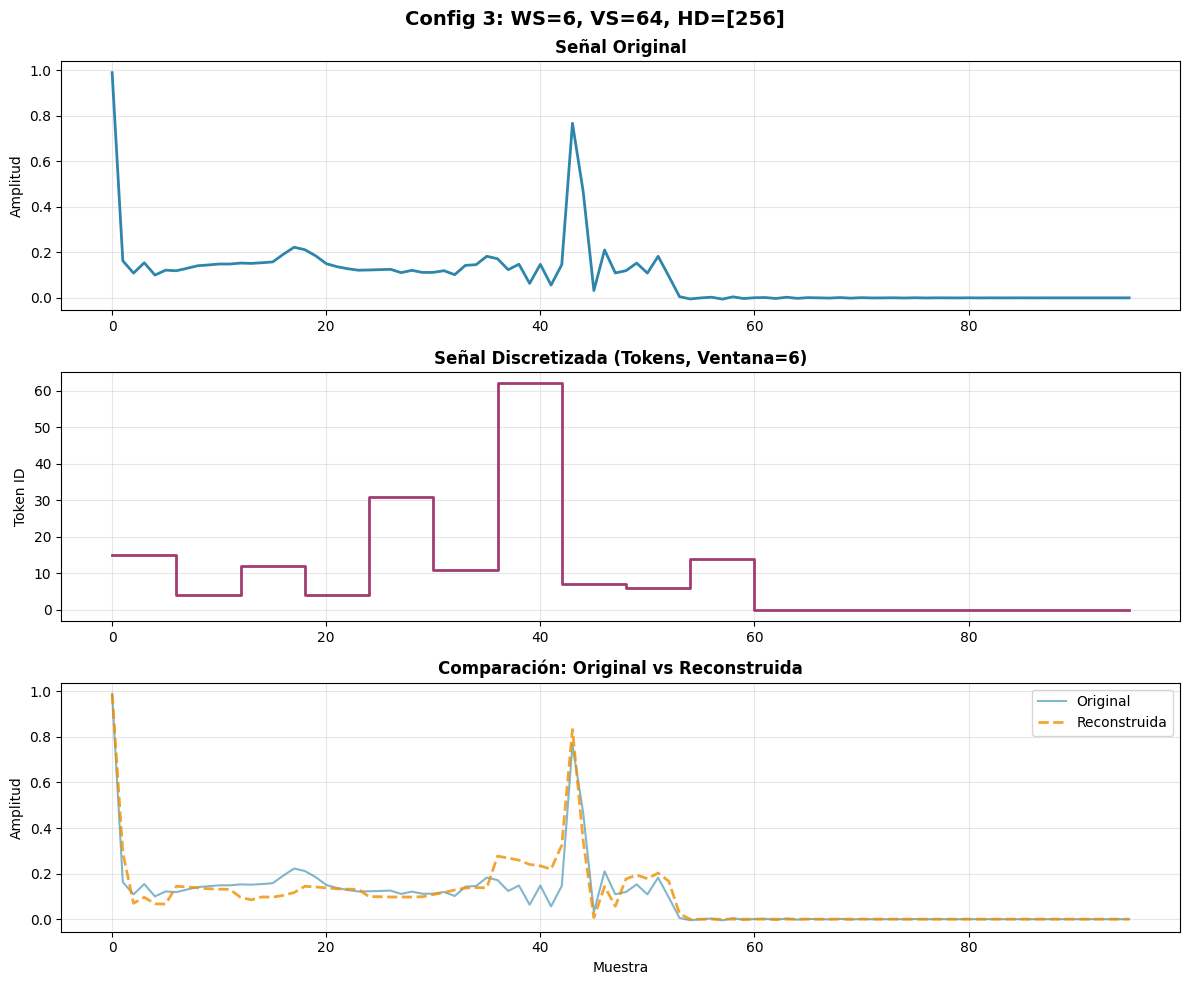


CONFIGURACIÓN 4/6
WINDOW_SIZE: 8, VOCAB_SIZE: 128, HIDDEN_DIMS: [512]



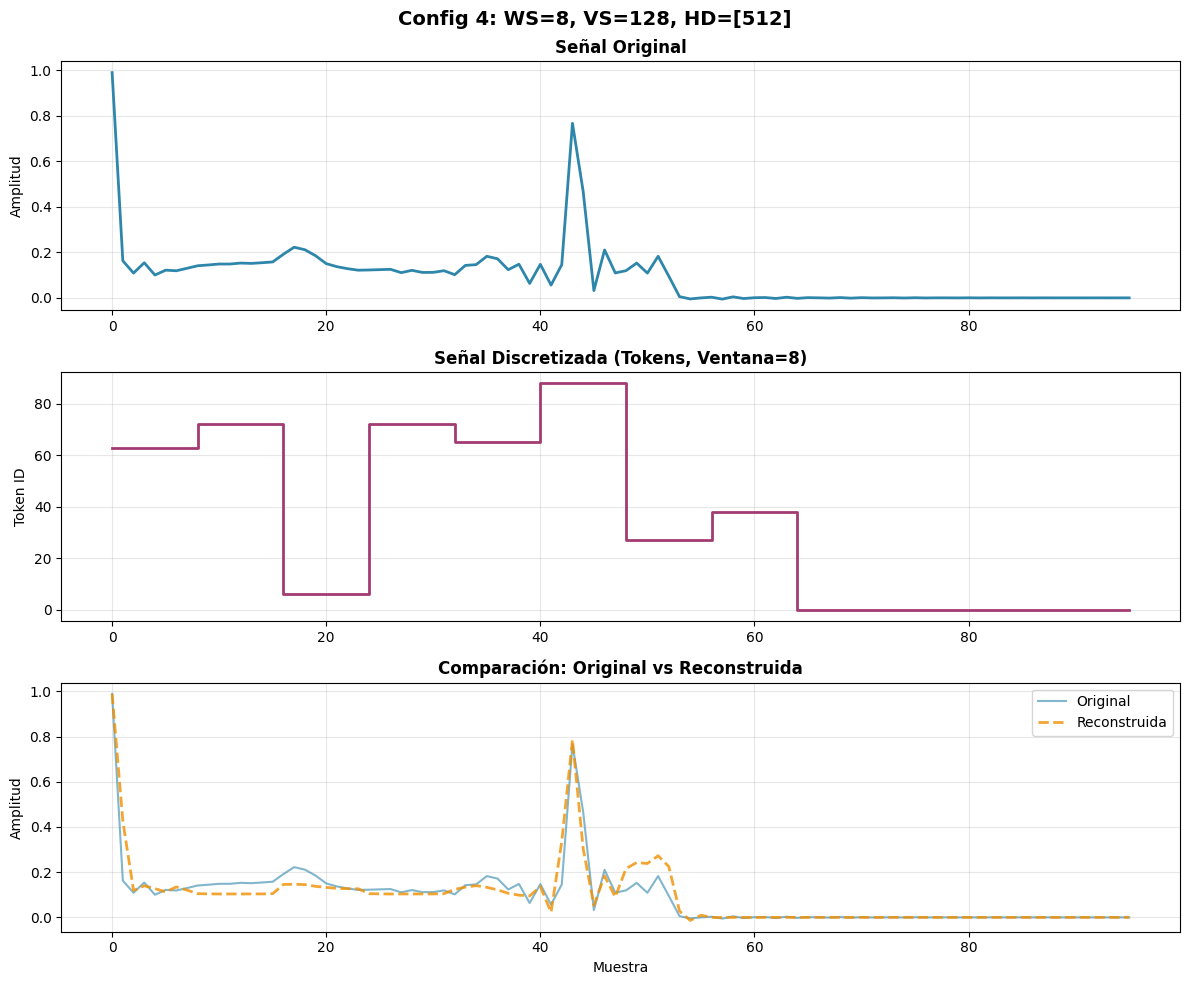


CONFIGURACIÓN 5/6
WINDOW_SIZE: 6, VOCAB_SIZE: 256, HIDDEN_DIMS: [128]



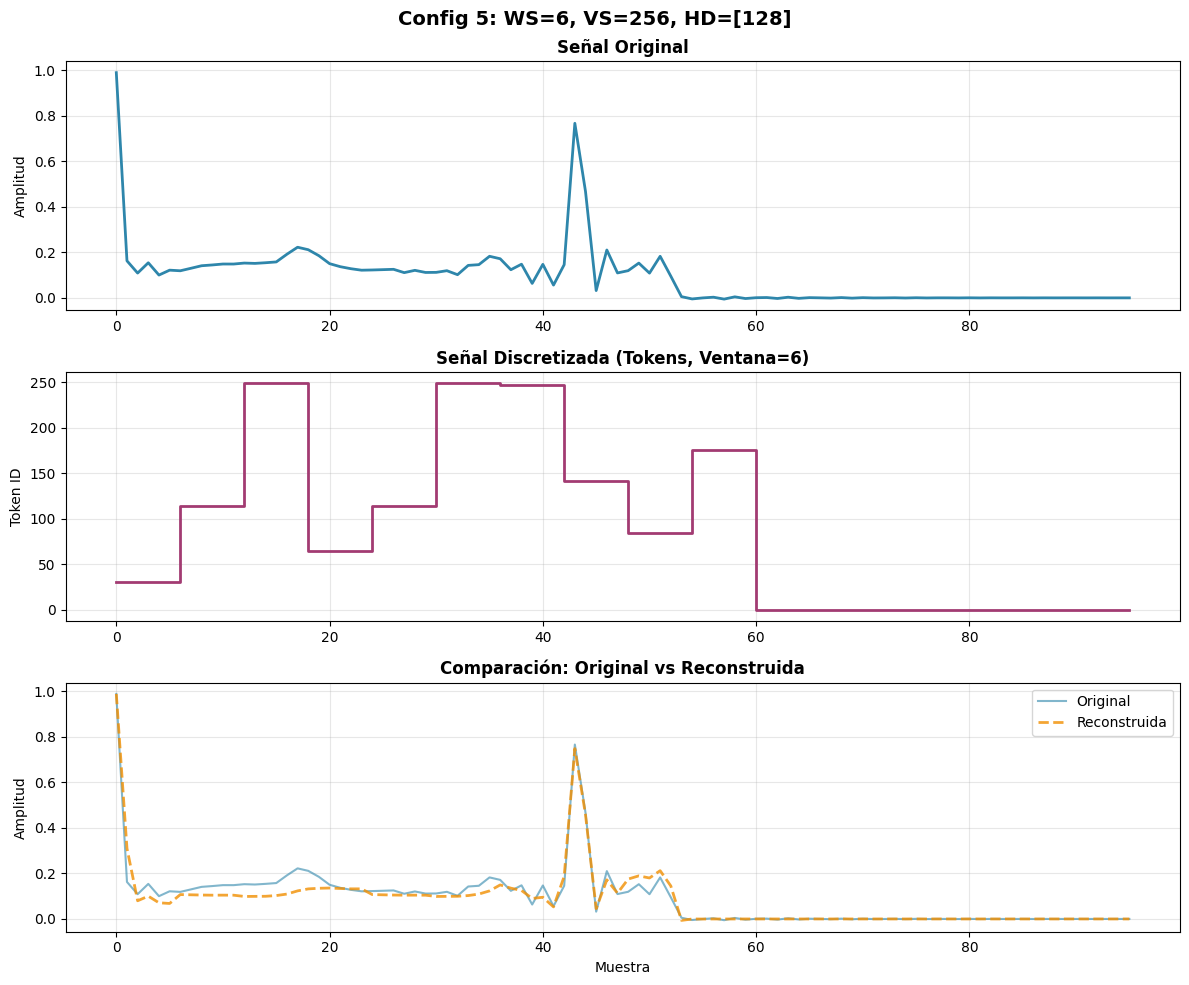


CONFIGURACIÓN 6/6
WINDOW_SIZE: 4, VOCAB_SIZE: 64, HIDDEN_DIMS: [512]



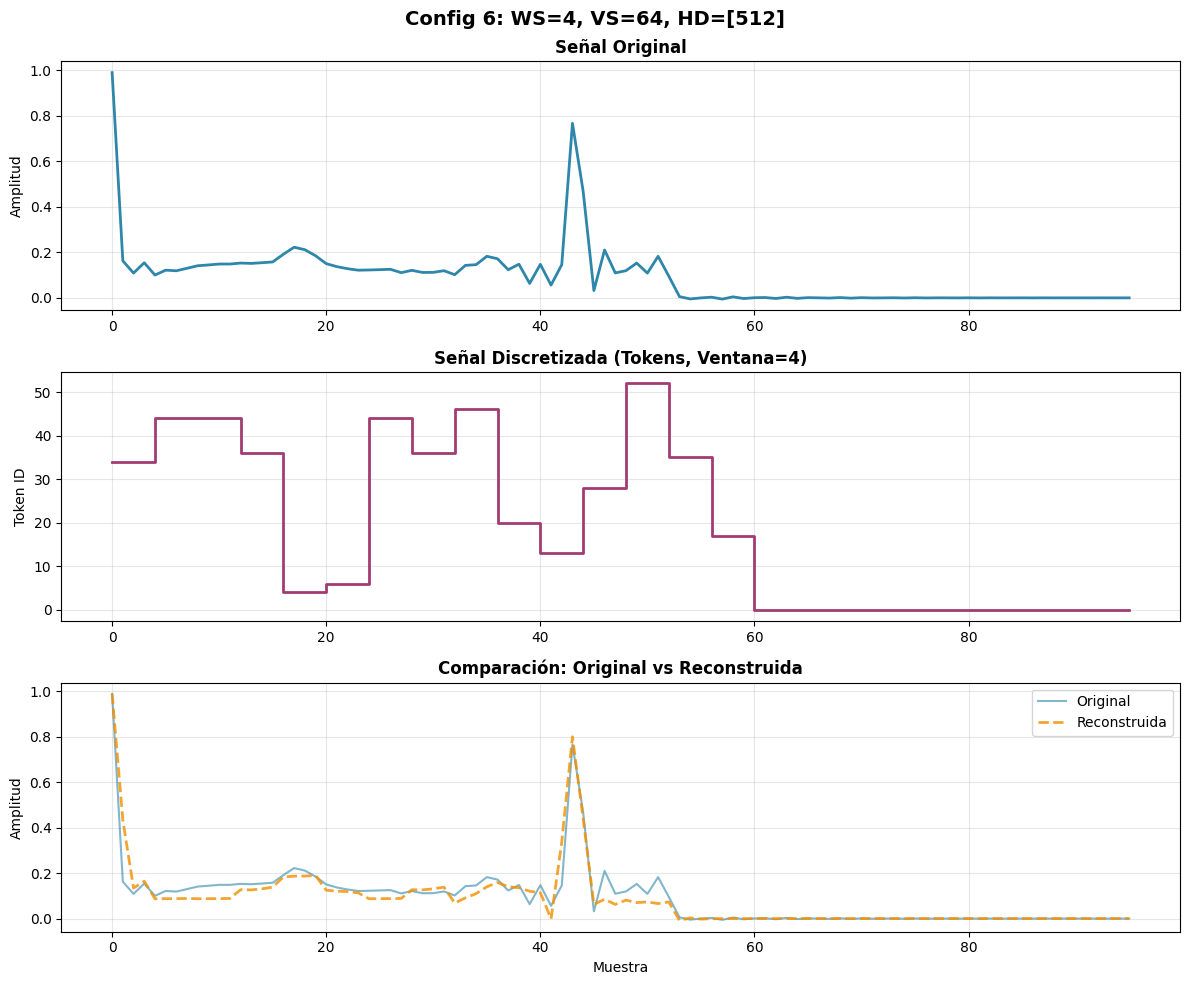


Discretización completada para todas las configuraciones


In [5]:
# Grid search configurations
param_grid = [
    {'WINDOW_SIZE': 6, 'VOCAB_SIZE': 128, 'HIDDEN_DIMS': [256]},
    {'WINDOW_SIZE': 4, 'VOCAB_SIZE': 128, 'HIDDEN_DIMS': [256]},
    {'WINDOW_SIZE': 6, 'VOCAB_SIZE': 64, 'HIDDEN_DIMS': [256]},
    {'WINDOW_SIZE': 8, 'VOCAB_SIZE': 128, 'HIDDEN_DIMS': [512]},
    {'WINDOW_SIZE': 6, 'VOCAB_SIZE': 256, 'HIDDEN_DIMS': [128]},
    {'WINDOW_SIZE': 4, 'VOCAB_SIZE': 64, 'HIDDEN_DIMS': [512]},
]

results = []

for idx, params in enumerate(param_grid):
    print(f"\n{'='*80}")
    print(f"CONFIGURACIÓN {idx+1}/6")
    print(f"WINDOW_SIZE: {params['WINDOW_SIZE']}, VOCAB_SIZE: {params['VOCAB_SIZE']}, HIDDEN_DIMS: {params['HIDDEN_DIMS']}")
    print(f"{'='*80}\n")
    
    WINDOW_SIZE = params['WINDOW_SIZE']
    VOCAB_SIZE = params['VOCAB_SIZE']
    HIDDEN_DIMS = params['HIDDEN_DIMS']
    
    # Discretization
    X_windows = X_discretization.reshape(-1, WINDOW_SIZE)
    gmm = GaussianMixture(n_components=VOCAB_SIZE, covariance_type='full', random_state=42)
    gmm.fit(X_windows)
    
    # Visualize discretization
    sample_signal = X_discretization[0:1]
    sample_tokens = discretize_signals(sample_signal, WINDOW_SIZE, gmm)
    sample_reconstructed = reconstruct_signals(sample_tokens, WINDOW_SIZE, gmm)
    sample_discretized = np.repeat(sample_tokens[0], WINDOW_SIZE)
    
    fig, axes = plt.subplots(3, 1, figsize=(12, 10))
    fig.suptitle(f'Config {idx+1}: WS={WINDOW_SIZE}, VS={VOCAB_SIZE}, HD={HIDDEN_DIMS}', fontsize=14, fontweight='bold')
    
    axes[0].plot(sample_signal[0], color='#2E86AB', linewidth=2)
    axes[0].set_title('Señal Original', fontsize=12, fontweight='bold')
    axes[0].set_ylabel('Amplitud')
    axes[0].grid(True, alpha=0.3)
    
    axes[1].step(range(len(sample_discretized)), sample_discretized, where='post', color='#A23B72', linewidth=2)
    axes[1].set_title(f'Señal Discretizada (Tokens, Ventana={WINDOW_SIZE})', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('Token ID')
    axes[1].grid(True, alpha=0.3)
    
    axes[2].plot(sample_signal[0], label='Original', alpha=0.6, color='#2E86AB', linewidth=1.5)
    axes[2].plot(sample_reconstructed[0], label='Reconstruida', alpha=0.8, color='#F18F01', linewidth=2, linestyle='--')
    axes[2].set_title('Comparación: Original vs Reconstruida', fontsize=12, fontweight='bold')
    axes[2].set_ylabel('Amplitud')
    axes[2].set_xlabel('Muestra')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Store params for later use
    results.append({
        'params': params,
        'gmm': gmm,
        'WINDOW_SIZE': WINDOW_SIZE,
        'VOCAB_SIZE': VOCAB_SIZE,
        'HIDDEN_DIMS': HIDDEN_DIMS
    })

print("\nDiscretización completada para todas las configuraciones")

In [6]:
# Prepare datasets for all configurations
for idx, result in enumerate(results):
    print(f"\nPreparando datasets para Config {idx+1}...")
    WINDOW_SIZE = result['WINDOW_SIZE']
    VOCAB_SIZE = result['VOCAB_SIZE']
    gmm = result['gmm']
    
    X_autoreg_tokens = discretize_signals(X_autoreg, WINDOW_SIZE, gmm)
    X_train, X_temp = train_test_split(X_autoreg_tokens, test_size=0.5, random_state=42)
    X_val, X_test = train_test_split(X_temp, test_size=0.5, random_state=42)
    
    train_ds = ECGTokenDataset(X_train, VOCAB_SIZE)
    val_ds = ECGTokenDataset(X_val, VOCAB_SIZE)
    test_ds = ECGTokenDataset(X_test, VOCAB_SIZE)
    
    train_dl = DataLoader(train_ds, batch_size=64, shuffle=True)
    val_dl = DataLoader(val_ds, batch_size=64, shuffle=False)
    
    result['train_ds'] = train_ds
    result['val_ds'] = val_ds
    result['test_ds'] = test_ds
    result['train_dl'] = train_dl
    result['val_dl'] = val_dl
    result['X_test'] = X_test

print("\nDatasets preparados para todas las configuraciones")


Preparando datasets para Config 1...

Preparando datasets para Config 2...

Preparando datasets para Config 2...

Preparando datasets para Config 3...

Preparando datasets para Config 3...

Preparando datasets para Config 4...

Preparando datasets para Config 4...

Preparando datasets para Config 5...

Preparando datasets para Config 5...

Preparando datasets para Config 6...

Preparando datasets para Config 6...

Datasets preparados para todas las configuraciones

Datasets preparados para todas las configuraciones



ENTRENANDO CONFIGURACIÓN 1/6
WINDOW_SIZE: 6, VOCAB_SIZE: 128, HIDDEN_DIMS: [256]



T-Loss: 24.1437 V-Loss: 32.3570: 100%|██████████| 200/200 [00:57<00:00,  3.49it/s] 



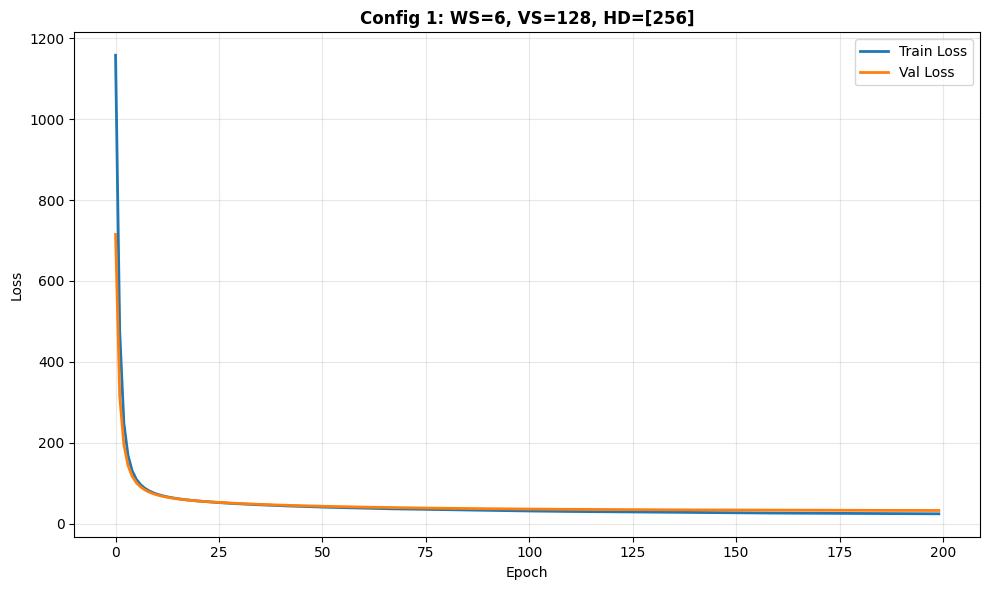


ENTRENANDO CONFIGURACIÓN 2/6
WINDOW_SIZE: 4, VOCAB_SIZE: 128, HIDDEN_DIMS: [256]



T-Loss: 35.0539 V-Loss: 51.6468: 100%|██████████| 200/200 [01:04<00:00,  3.11it/s] 



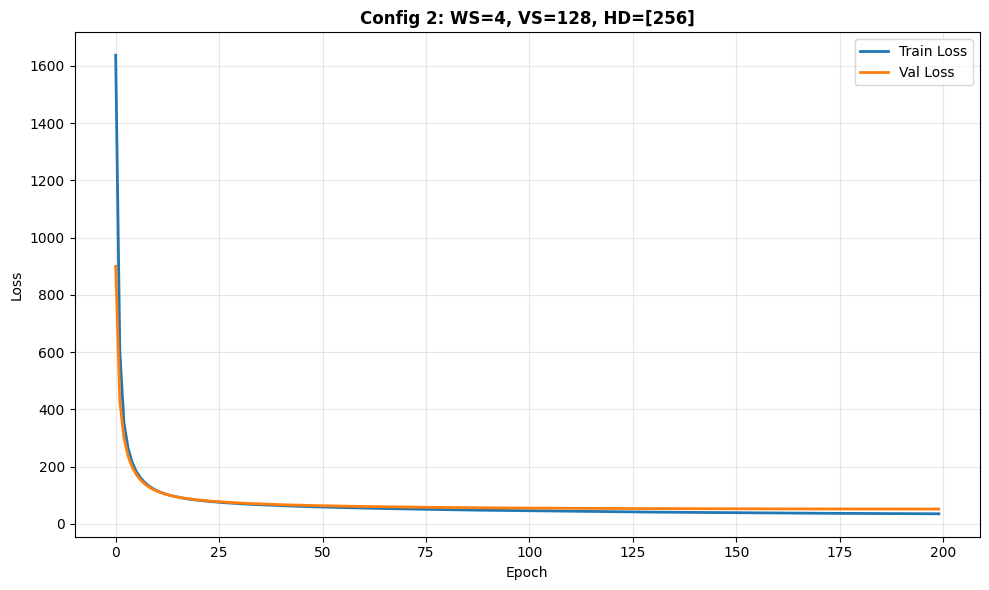


ENTRENANDO CONFIGURACIÓN 3/6
WINDOW_SIZE: 6, VOCAB_SIZE: 64, HIDDEN_DIMS: [256]



T-Loss: 19.4367 V-Loss: 25.0969: 100%|██████████| 200/200 [00:49<00:00,  4.04it/s]



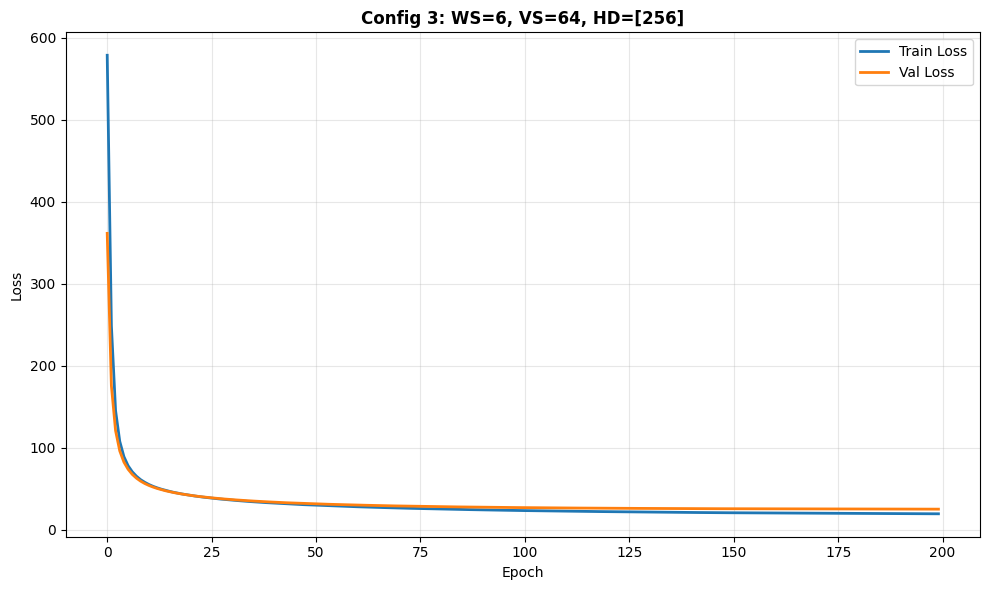


ENTRENANDO CONFIGURACIÓN 4/6
WINDOW_SIZE: 8, VOCAB_SIZE: 128, HIDDEN_DIMS: [512]



T-Loss: 15.2190 V-Loss: 21.9412: 100%|██████████| 200/200 [01:04<00:00,  3.12it/s]



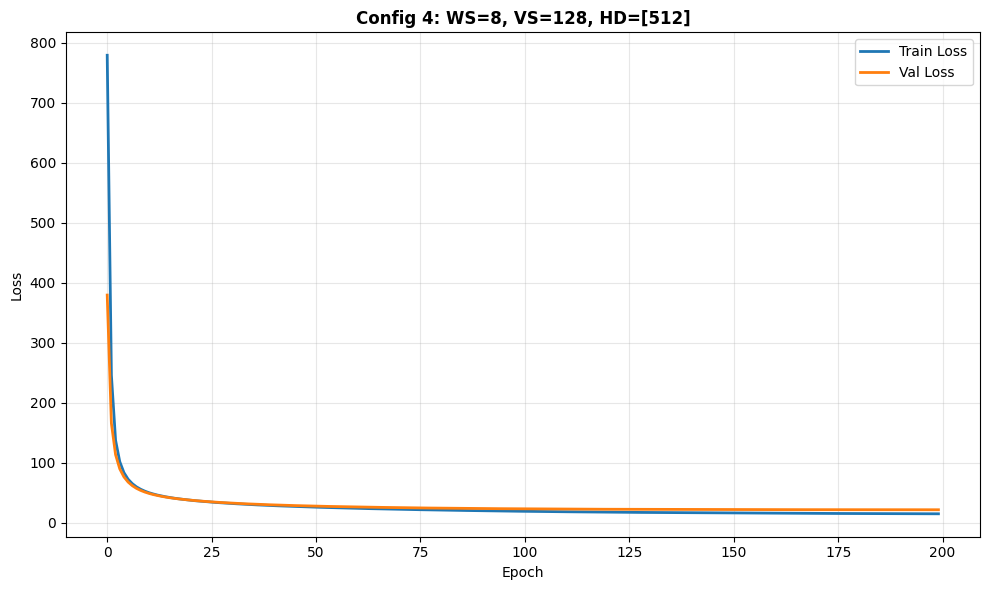


ENTRENANDO CONFIGURACIÓN 5/6
WINDOW_SIZE: 6, VOCAB_SIZE: 256, HIDDEN_DIMS: [128]



T-Loss: 34.5352 V-Loss: 40.3184: 100%|██████████| 200/200 [01:11<00:00,  2.82it/s]  



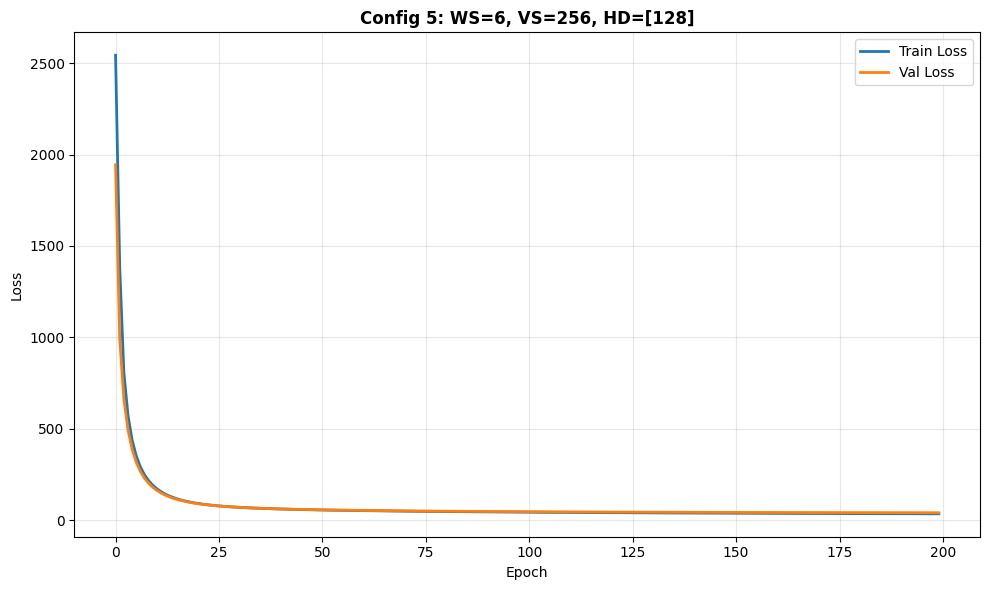


ENTRENANDO CONFIGURACIÓN 6/6
WINDOW_SIZE: 4, VOCAB_SIZE: 64, HIDDEN_DIMS: [512]



T-Loss: 23.1610 V-Loss: 39.8670: 100%|██████████| 200/200 [01:07<00:00,  2.95it/s]



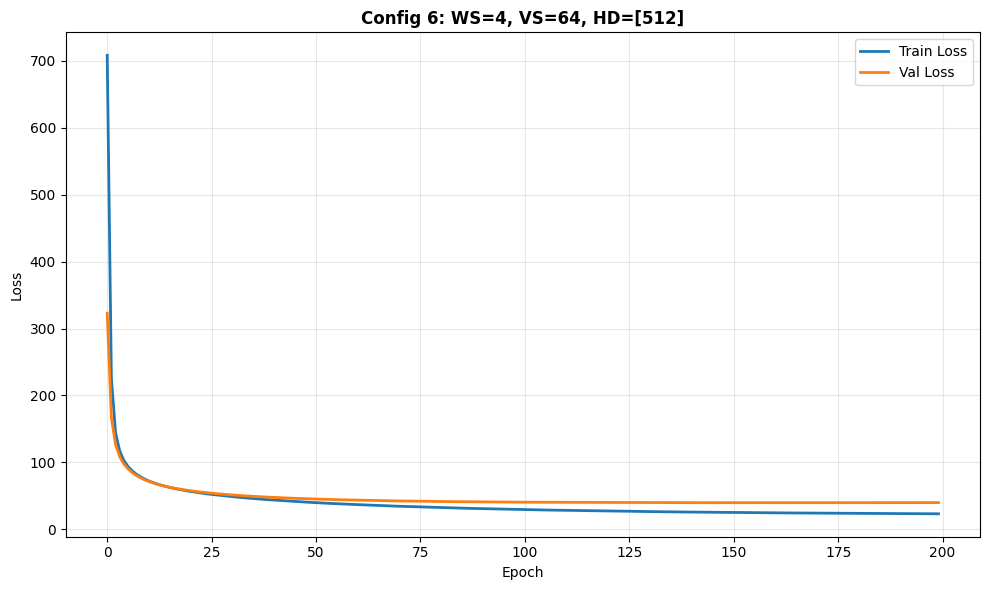


Entrenamiento completado para todas las configuraciones


In [7]:
LR = 1e-3
EPOCHS = 200

def loss_fn(inputs, preds):
    loss = F.binary_cross_entropy_with_logits(preds, inputs, reduction='none')
    return loss.sum(dim=1).mean()

def train_validate_loop(model, optimizer, scheduler, loss_fn, train_loader, val_loader, epochs):
    train_losses = []
    val_losses = []
    
    pbar = tqdm(range(epochs))
    for epoch in pbar:
        model.train()
        running_loss = 0.0
        for i, data in enumerate(train_loader):
            inputs = data.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = loss_fn(inputs, outputs)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        
        avg_train_loss = running_loss / len(train_loader)
        train_losses.append(avg_train_loss)
        
        model.eval()
        running_val_loss = 0.0
        with torch.no_grad():
            for i, data in enumerate(val_loader):
                inputs = data.to(device)
                outputs = model(inputs)
                loss = loss_fn(inputs, outputs)
                running_val_loss += loss.item()
        
        avg_val_loss = running_val_loss / len(val_loader)
        val_losses.append(avg_val_loss)

        if scheduler:
            scheduler.step()
            
        pbar.set_description(f'T-Loss: {avg_train_loss:.4f} V-Loss: {avg_val_loss:.4f}')

    return train_losses, val_losses

# Train models for all configurations
for idx, result in enumerate(results):
    print(f"\n{'='*80}")
    print(f"ENTRENANDO CONFIGURACIÓN {idx+1}/6")
    print(f"WINDOW_SIZE: {result['WINDOW_SIZE']}, VOCAB_SIZE: {result['VOCAB_SIZE']}, HIDDEN_DIMS: {result['HIDDEN_DIMS']}")
    print(f"{'='*80}\n")
    
    seq_len = X_padded.shape[1] // result['WINDOW_SIZE']
    input_dim = seq_len * result['VOCAB_SIZE']
    
    made_model = models.MADE(input_dim=input_dim, hidden_dims=result['HIDDEN_DIMS'], n_masks=1)
    made_model.to(device)
    
    optimizer = optim.Adam(made_model.parameters(), lr=LR, weight_decay=1e-4)
    scheduler = lr_scheduler.MultiplicativeLR(optimizer, lr_lambda=lambda _: 0.99)
    
    train_hist, val_hist = train_validate_loop(made_model, optimizer, scheduler, loss_fn, 
                                                result['train_dl'], result['val_dl'], EPOCHS)
    
    result['model'] = made_model
    result['train_hist'] = train_hist
    result['val_hist'] = val_hist
    result['seq_len'] = seq_len
    
    # Plot training curves
    plt.figure(figsize=(10, 6))
    plt.plot(train_hist, label='Train Loss', linewidth=2)
    plt.plot(val_hist, label='Val Loss', linewidth=2)
    plt.title(f'Config {idx+1}: WS={result["WINDOW_SIZE"]}, VS={result["VOCAB_SIZE"]}, HD={result["HIDDEN_DIMS"]}', 
              fontsize=12, fontweight='bold')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

print("\nEntrenamiento completado para todas las configuraciones")


EVALUANDO CONFIGURACIÓN 1/6
WINDOW_SIZE: 6, VOCAB_SIZE: 128, HIDDEN_DIMS: [256]



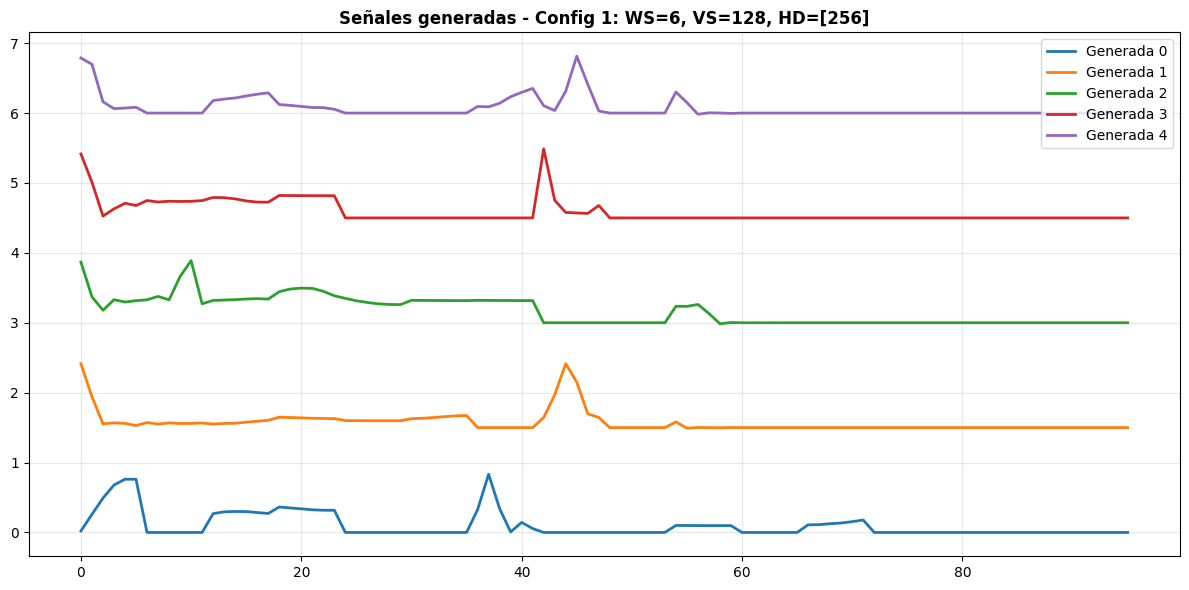

NLL promedio en Train: 24.0954
NLL promedio en Val: 32.3265
NLL promedio en Test: 32.7127


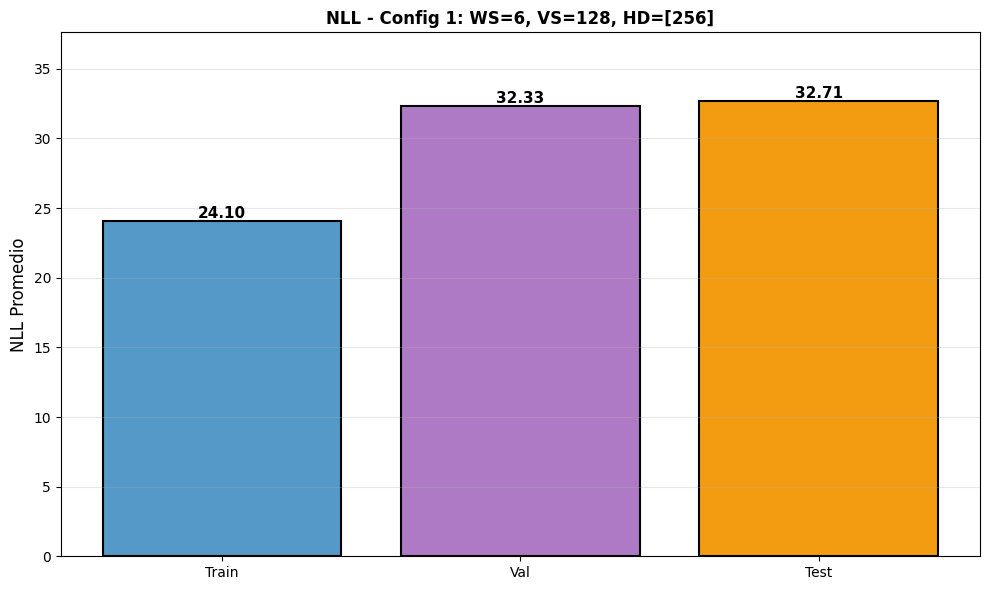

NLL promedio en Anomalías: 54.9409
Diferencia: 22.2283

--- Comparación Generadas vs Reales ---
Distancia Euclidiana promedio: 2.1808 ± 0.8138
Correlación de Pearson promedio: 0.4373 ± 0.1994
Distancia Euclidiana promedio: 2.1808 ± 0.8138
Correlación de Pearson promedio: 0.4373 ± 0.1994


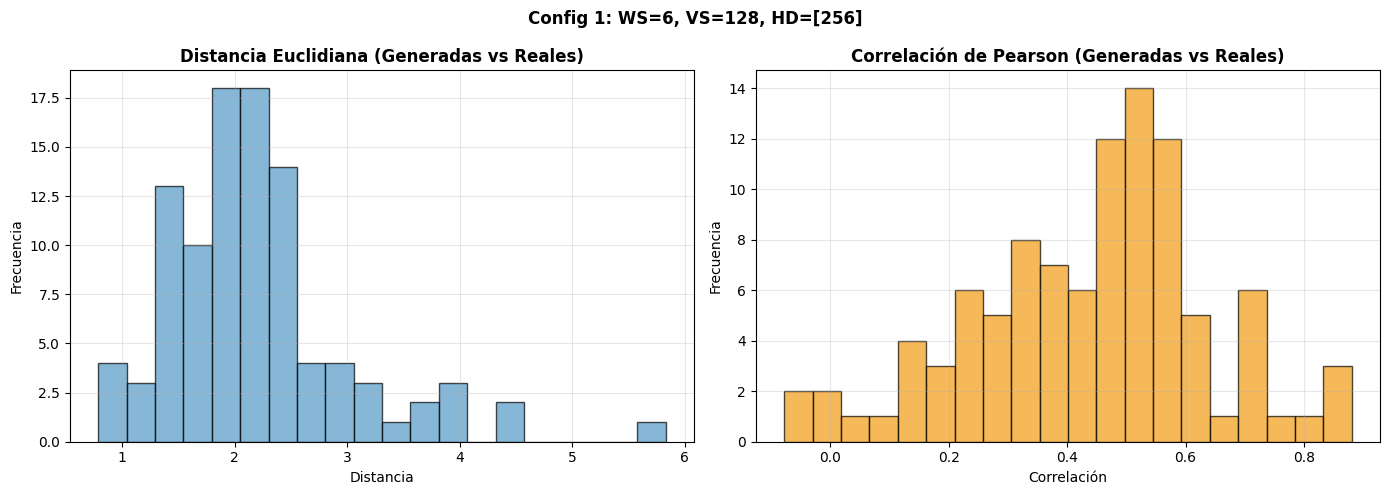


EVALUANDO CONFIGURACIÓN 2/6
WINDOW_SIZE: 4, VOCAB_SIZE: 128, HIDDEN_DIMS: [256]



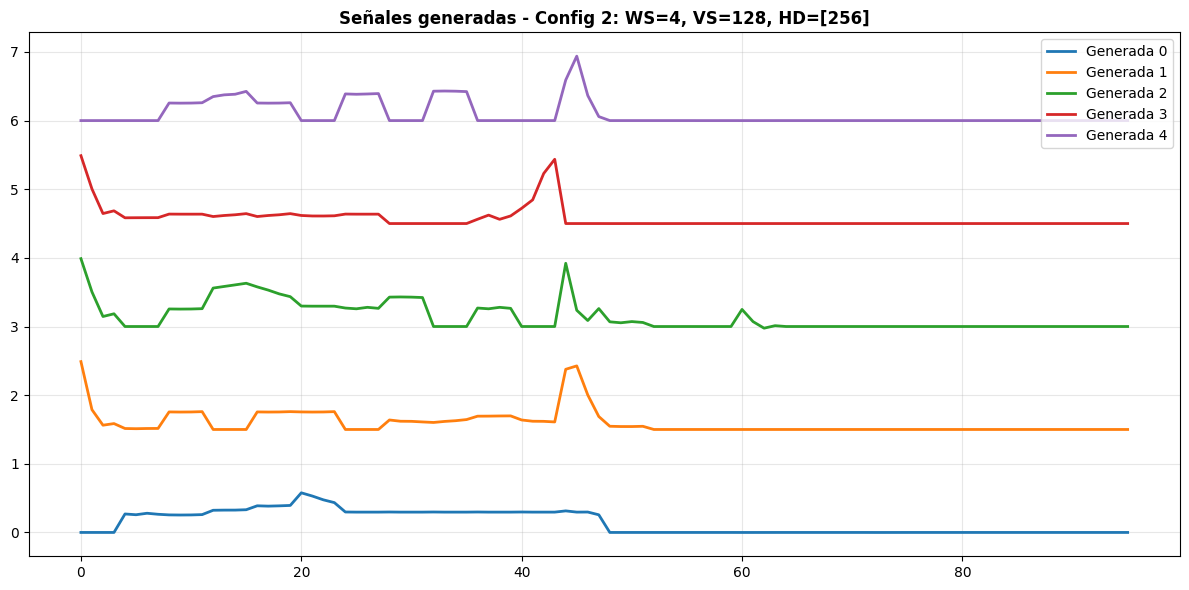

NLL promedio en Train: 35.0033
NLL promedio en Val: 51.6265
NLL promedio en Test: 51.5058


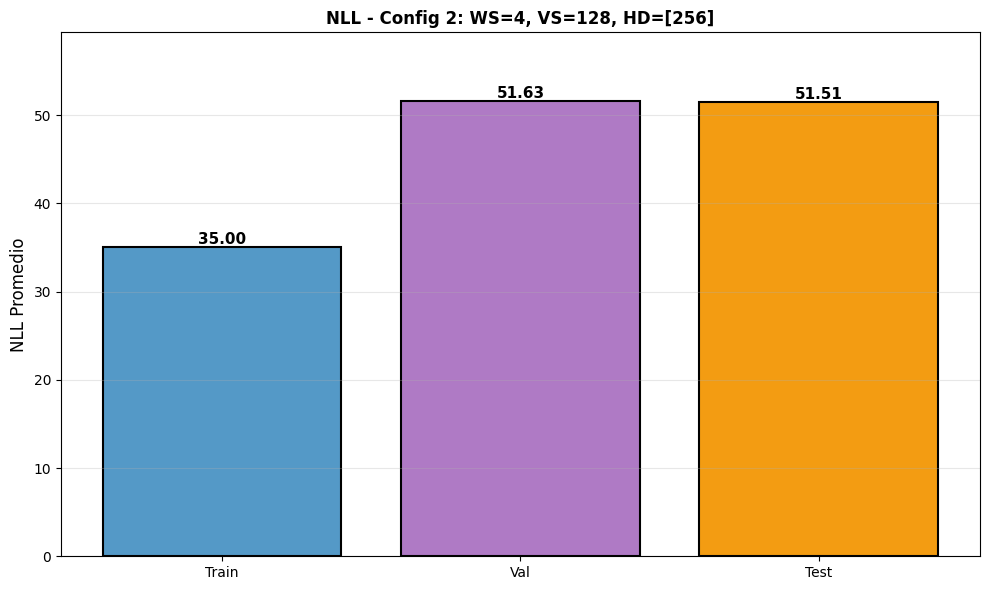

NLL promedio en Anomalías: 87.7859
Diferencia: 36.2801

--- Comparación Generadas vs Reales ---
Distancia Euclidiana promedio: 2.1185 ± 0.7637
Correlación de Pearson promedio: 0.4135 ± 0.2019
Distancia Euclidiana promedio: 2.1185 ± 0.7637
Correlación de Pearson promedio: 0.4135 ± 0.2019


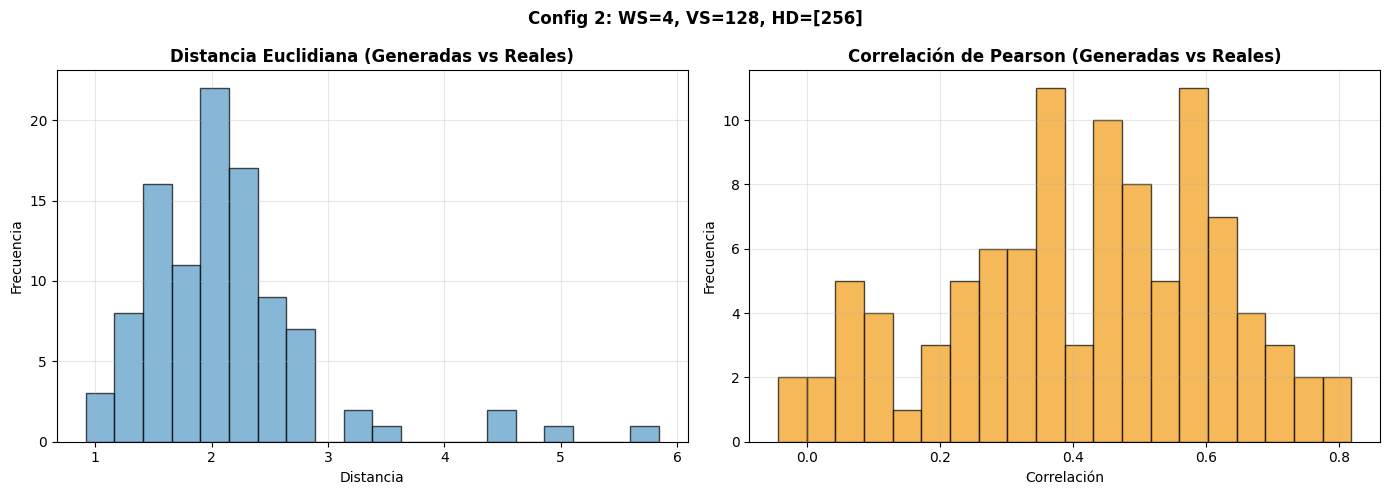


EVALUANDO CONFIGURACIÓN 3/6
WINDOW_SIZE: 6, VOCAB_SIZE: 64, HIDDEN_DIMS: [256]



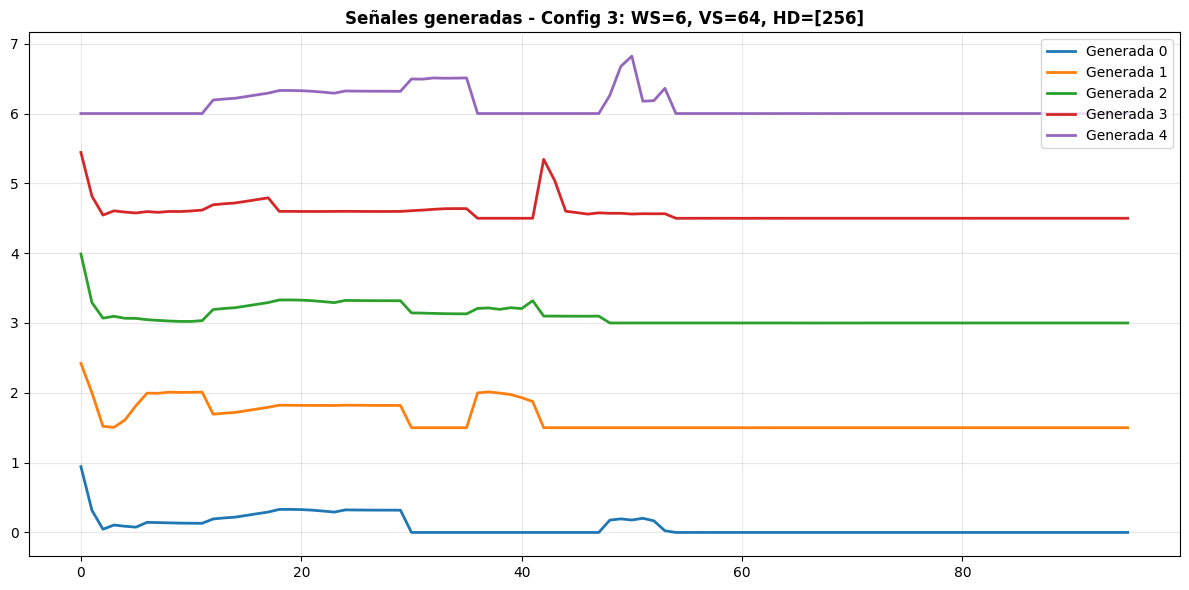

NLL promedio en Train: 19.3871
NLL promedio en Val: 25.1088
NLL promedio en Test: 25.5985


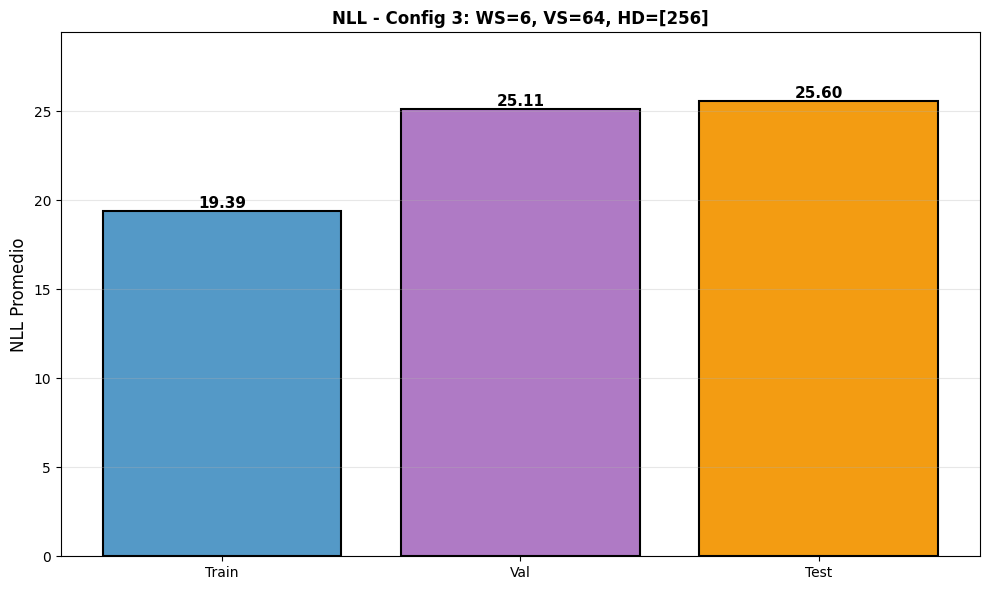

NLL promedio en Anomalías: 47.0012
Diferencia: 21.4027

--- Comparación Generadas vs Reales ---
Distancia Euclidiana promedio: 2.0141 ± 0.7327
Correlación de Pearson promedio: 0.4803 ± 0.1850
Distancia Euclidiana promedio: 2.0141 ± 0.7327
Correlación de Pearson promedio: 0.4803 ± 0.1850


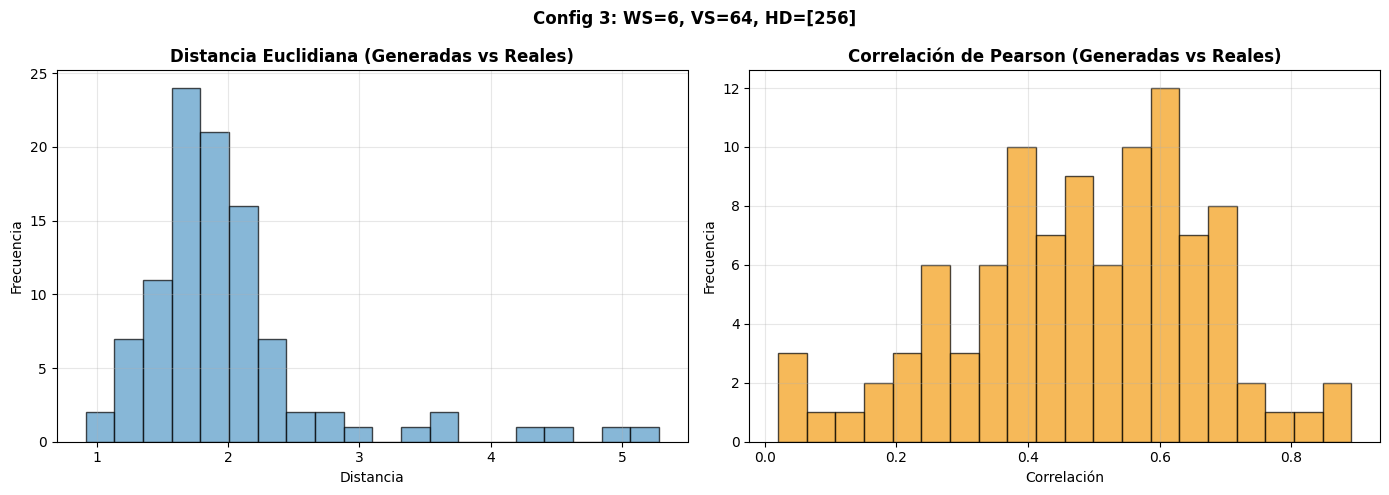


EVALUANDO CONFIGURACIÓN 4/6
WINDOW_SIZE: 8, VOCAB_SIZE: 128, HIDDEN_DIMS: [512]



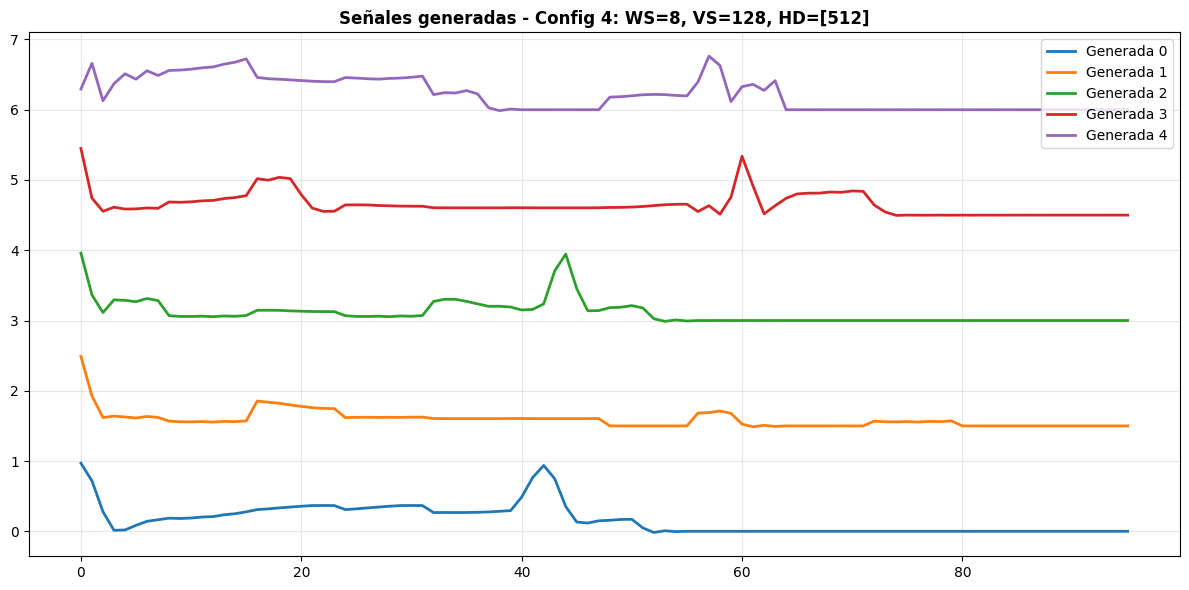

NLL promedio en Train: 15.1963
NLL promedio en Val: 21.9332
NLL promedio en Test: 22.5854


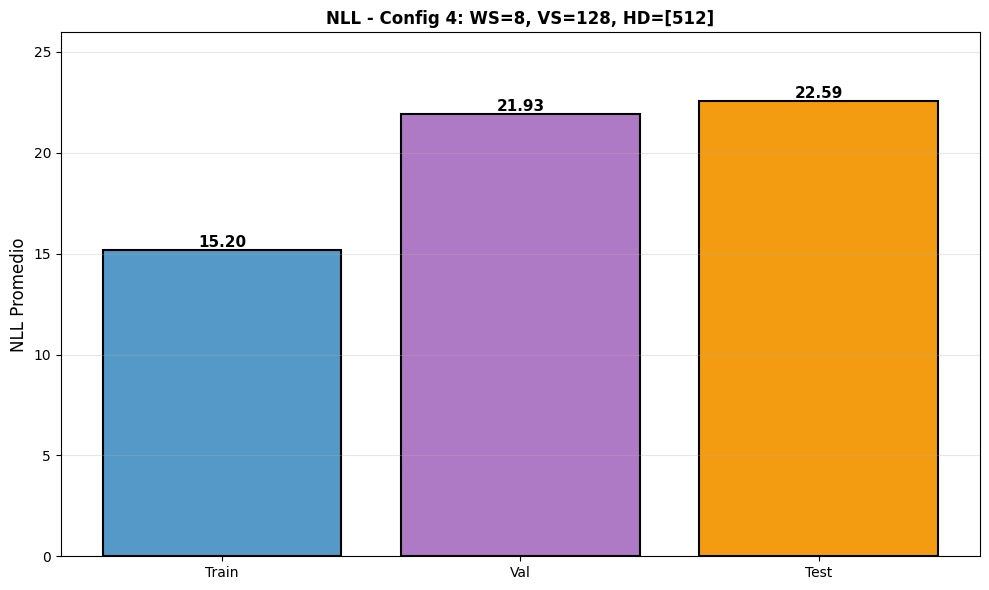

NLL promedio en Anomalías: 43.0720
Diferencia: 20.4866

--- Comparación Generadas vs Reales ---
Distancia Euclidiana promedio: 1.9799 ± 0.6972
Correlación de Pearson promedio: 0.4761 ± 0.2032
Distancia Euclidiana promedio: 1.9799 ± 0.6972
Correlación de Pearson promedio: 0.4761 ± 0.2032


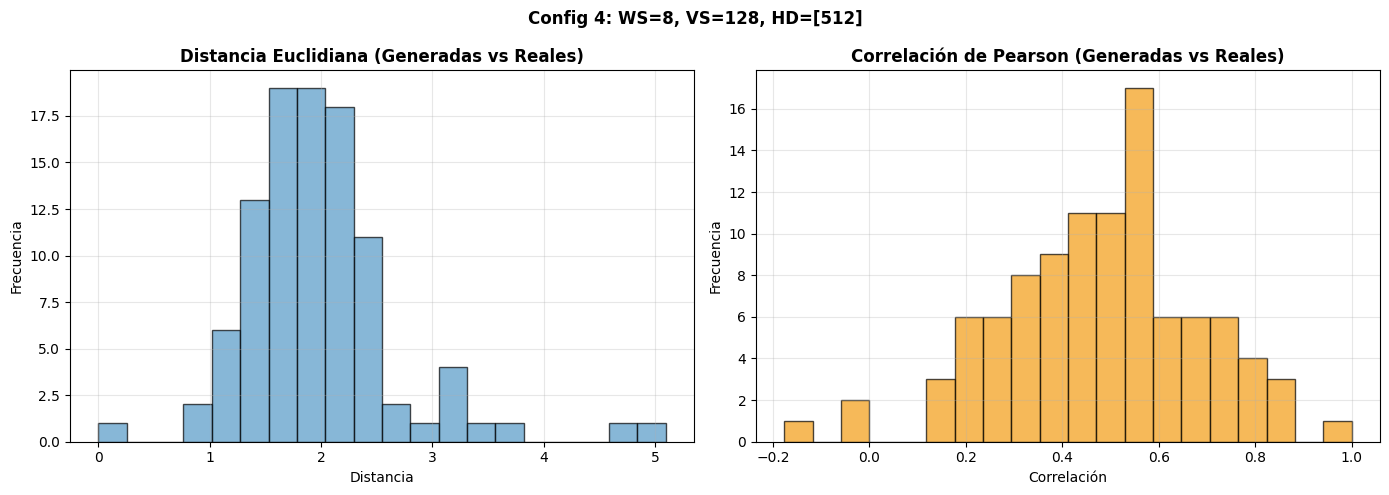


EVALUANDO CONFIGURACIÓN 5/6
WINDOW_SIZE: 6, VOCAB_SIZE: 256, HIDDEN_DIMS: [128]



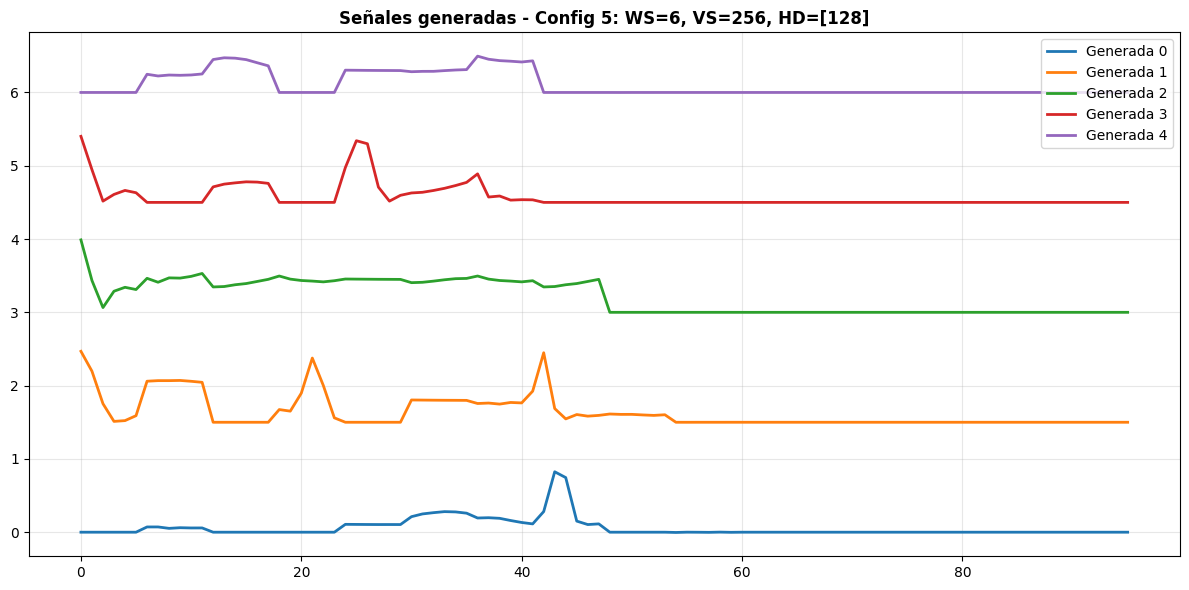

NLL promedio en Train: 34.4838
NLL promedio en Val: 40.3089
NLL promedio en Test: 40.8305


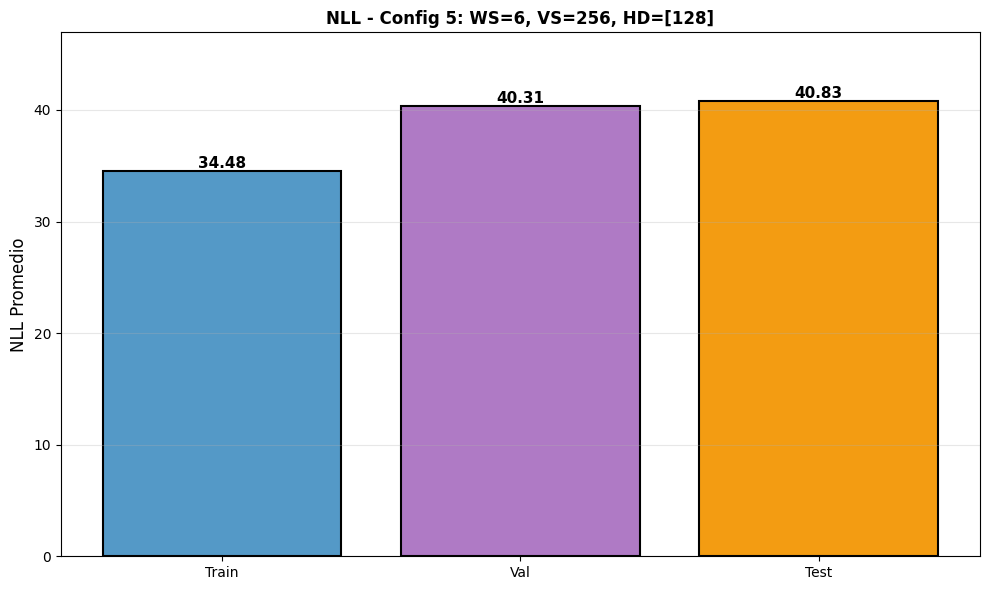

NLL promedio en Anomalías: 61.5636
Diferencia: 20.7331

--- Comparación Generadas vs Reales ---
Distancia Euclidiana promedio: 2.2060 ± 0.7337
Correlación de Pearson promedio: 0.3411 ± 0.1969
Distancia Euclidiana promedio: 2.2060 ± 0.7337
Correlación de Pearson promedio: 0.3411 ± 0.1969


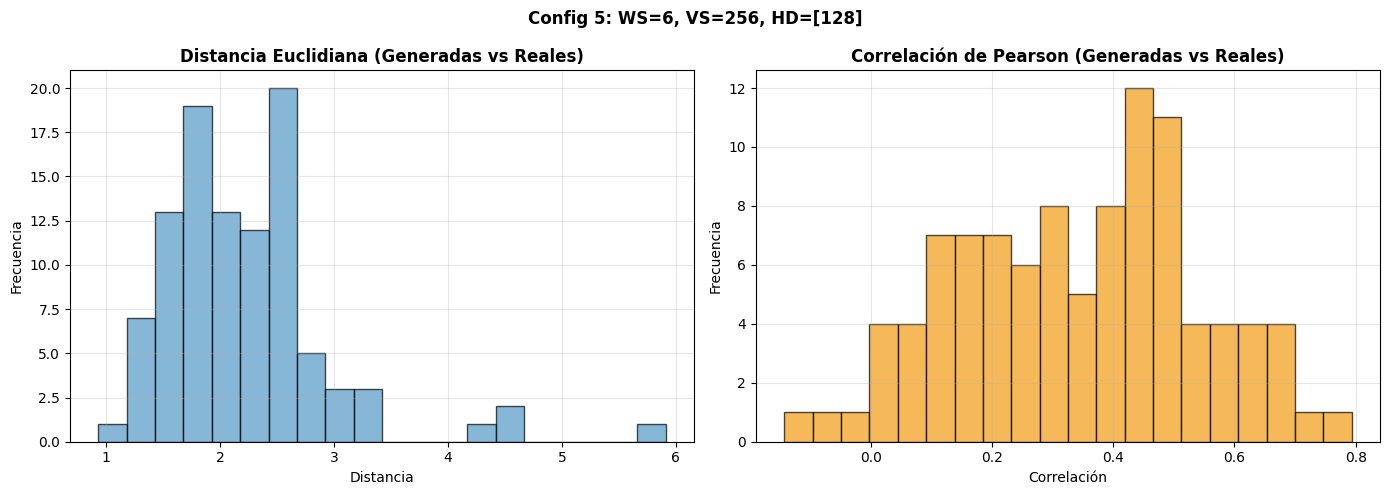


EVALUANDO CONFIGURACIÓN 6/6
WINDOW_SIZE: 4, VOCAB_SIZE: 64, HIDDEN_DIMS: [512]



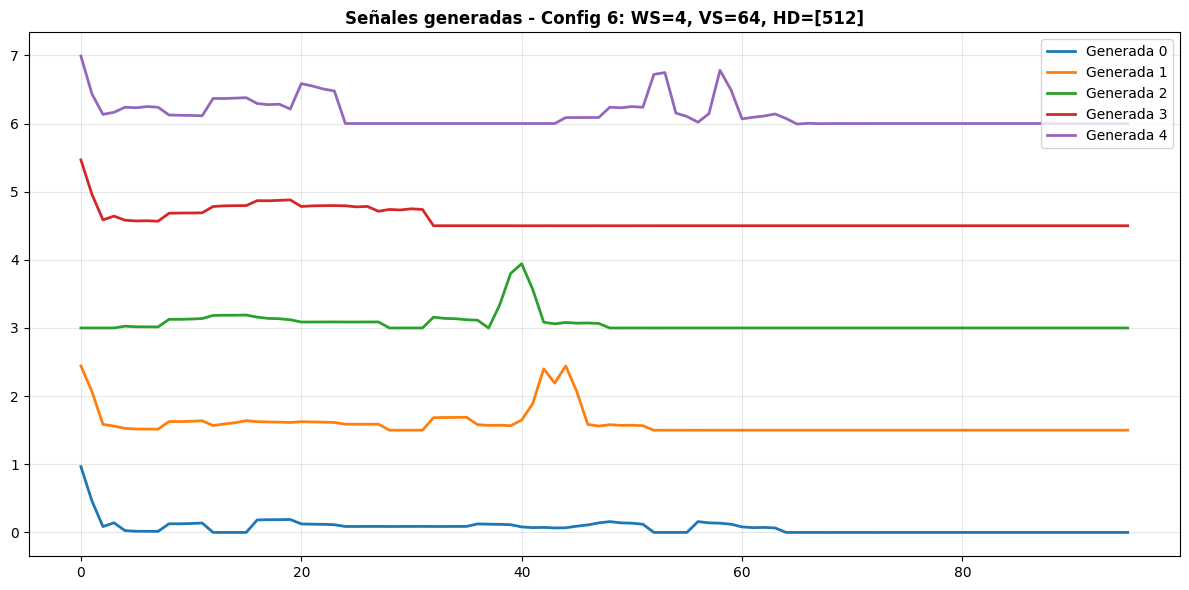

NLL promedio en Train: 23.0975
NLL promedio en Val: 39.8299
NLL promedio en Test: 40.7122


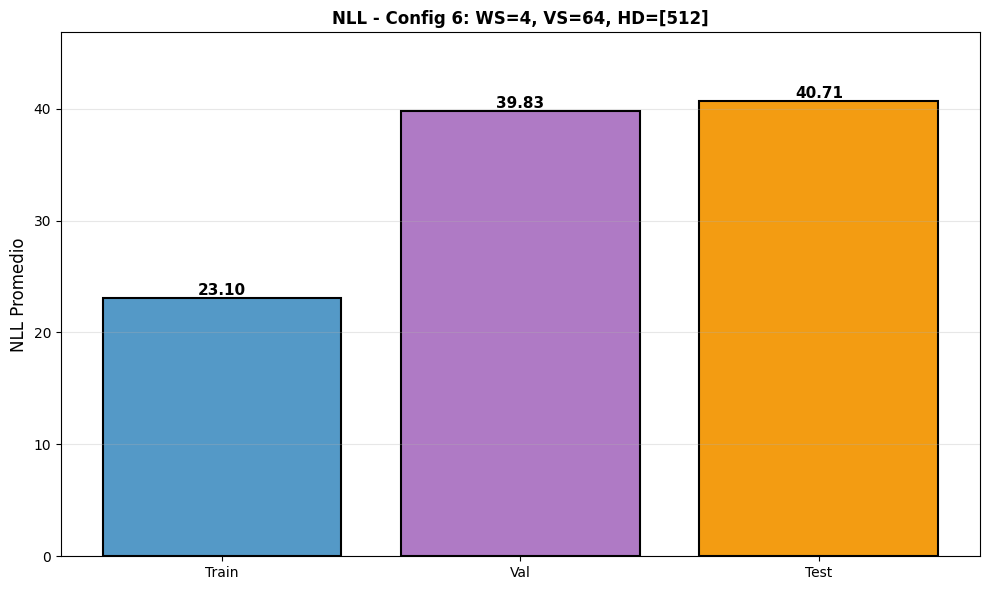

NLL promedio en Anomalías: 79.4638
Diferencia: 38.7516

--- Comparación Generadas vs Reales ---
Distancia Euclidiana promedio: 1.9437 ± 0.7394
Correlación de Pearson promedio: 0.4943 ± 0.1911
Distancia Euclidiana promedio: 1.9437 ± 0.7394
Correlación de Pearson promedio: 0.4943 ± 0.1911


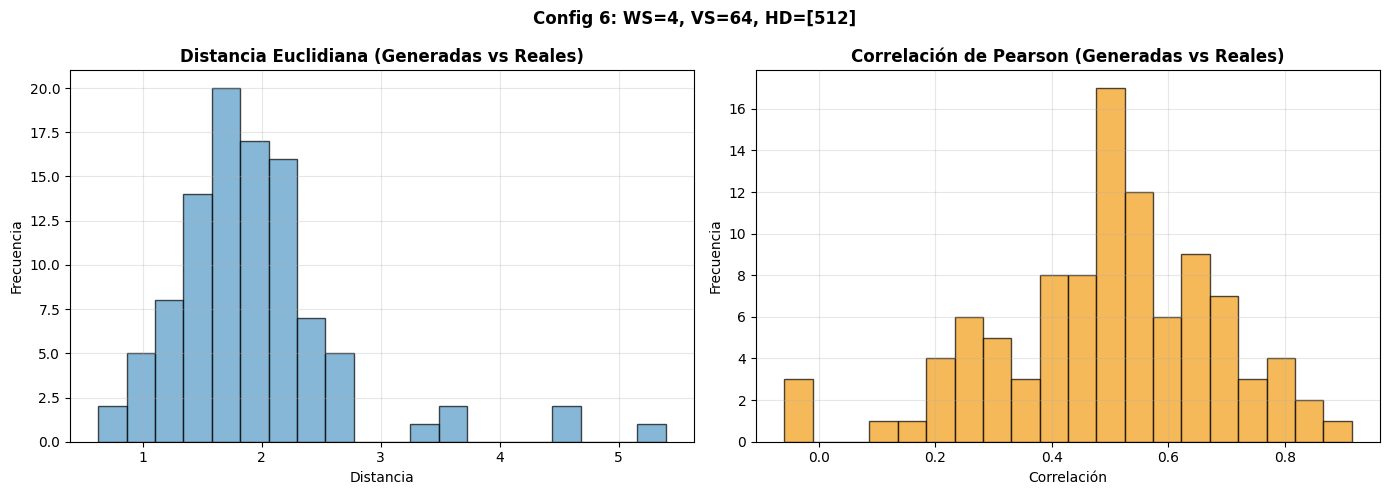


Evaluación completada para todas las configuraciones


In [8]:
def calculate_nll(model, dataset):
    loader = DataLoader(dataset, batch_size=32, shuffle=False)
    model.eval()
    total_nll = 0
    with torch.no_grad():
        for inputs in loader:
            inputs = inputs.to(device)
            logits = model(inputs)
            probs = torch.sigmoid(logits)
            epsilon = 1e-10
            batch_nll = - (inputs * torch.log(probs + epsilon) + (1 - inputs) * torch.log(1 - probs + epsilon)).sum(dim=1)
            total_nll += batch_nll.sum().item()
            
    return total_nll / len(dataset)

# Generate samples and calculate NLL for all configurations
for idx, result in enumerate(results):
    print(f"\n{'='*80}")
    print(f"EVALUANDO CONFIGURACIÓN {idx+1}/6")
    print(f"WINDOW_SIZE: {result['WINDOW_SIZE']}, VOCAB_SIZE: {result['VOCAB_SIZE']}, HIDDEN_DIMS: {result['HIDDEN_DIMS']}")
    print(f"{'='*80}\n")
    
    model = result['model']
    seq_len = result['seq_len']
    VOCAB_SIZE = result['VOCAB_SIZE']
    WINDOW_SIZE = result['WINDOW_SIZE']
    gmm = result['gmm']
    
    # Generate samples
    gen_signals = generate_samples(model, 5, seq_len, VOCAB_SIZE, WINDOW_SIZE, gmm)
    plt.figure(figsize=(12, 6))
    for i in range(5):
        plt.plot(gen_signals[i] + i*1.5, label=f'Generada {i}', linewidth=2)
    plt.title(f"Señales generadas - Config {idx+1}: WS={WINDOW_SIZE}, VS={VOCAB_SIZE}, HD={result['HIDDEN_DIMS']}", 
              fontsize=12, fontweight='bold')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Calculate NLL
    nll_train = calculate_nll(model, result['train_ds'])
    nll_val = calculate_nll(model, result['val_ds'])
    nll_test = calculate_nll(model, result['test_ds'])
    
    print(f"NLL promedio en Train: {nll_train:.4f}")
    print(f"NLL promedio en Val: {nll_val:.4f}")
    print(f"NLL promedio en Test: {nll_test:.4f}")
    
    result['nll_train'] = nll_train
    result['nll_val'] = nll_val
    result['nll_test'] = nll_test
    
    # Plot NLL comparison
    nll_splits = {'Train': nll_train, 'Val': nll_val, 'Test': nll_test}
    labels_splits = list(nll_splits.keys())
    values_splits = list(nll_splits.values())
    colors_splits = ['#5499C7', '#AF7AC5', '#F39C12']
    
    plt.figure(figsize=(10, 6))
    bars = plt.bar(labels_splits, values_splits, color=colors_splits, edgecolor='black', linewidth=1.5)
    
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                 f'{height:.2f}',
                 ha='center', va='bottom', fontweight='bold', fontsize=11)
    
    plt.title(f'NLL - Config {idx+1}: WS={WINDOW_SIZE}, VS={VOCAB_SIZE}, HD={result["HIDDEN_DIMS"]}', 
              fontsize=12, fontweight='bold')
    plt.ylabel('NLL Promedio', fontsize=12)
    plt.grid(axis='y', linestyle='-', alpha=0.3)
    plt.ylim(0, max(values_splits) * 1.15)
    plt.tight_layout()
    plt.show()
    
    # Anomaly detection
    X_anom = X[y != 'Normal']
    if len(X_anom) > 0:
        X_anom_sample = X_anom[:200]
        X_anom_padded = np.hstack((X_anom_sample, np.zeros((X_anom_sample.shape[0], 2))))
        X_anom_tokens = discretize_signals(X_anom_padded, WINDOW_SIZE, gmm)
        anom_ds = ECGTokenDataset(X_anom_tokens, VOCAB_SIZE)
        nll_anomaly = calculate_nll(model, anom_ds)
        print(f"NLL promedio en Anomalías: {nll_anomaly:.4f}")
        print(f"Diferencia: {nll_anomaly - nll_test:.4f}")
        result['nll_anomaly'] = nll_anomaly
    
    # Compare generated vs real
    print("\n--- Comparación Generadas vs Reales ---")
    gen_samples_large = generate_samples(model, 100, seq_len, VOCAB_SIZE, WINDOW_SIZE, gmm)
    # Reconstruct real samples from tokens
    real_samples_reconstructed = reconstruct_signals(result['X_test'][:100], WINDOW_SIZE, gmm)
    
    from scipy.spatial.distance import euclidean
    from scipy.stats import pearsonr
    
    euclidean_dists = [euclidean(gen_samples_large[i], real_samples_reconstructed[i]) for i in range(100)]
    correlations = [pearsonr(gen_samples_large[i], real_samples_reconstructed[i])[0] for i in range(100)]
    
    print(f"Distancia Euclidiana promedio: {np.mean(euclidean_dists):.4f} ± {np.std(euclidean_dists):.4f}")
    print(f"Correlación de Pearson promedio: {np.mean(correlations):.4f} ± {np.std(correlations):.4f}")
    
    result['euclidean_mean'] = np.mean(euclidean_dists)
    result['correlation_mean'] = np.mean(correlations)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Config {idx+1}: WS={WINDOW_SIZE}, VS={VOCAB_SIZE}, HD={result["HIDDEN_DIMS"]}', 
                 fontsize=12, fontweight='bold')
    
    axes[0].hist(euclidean_dists, bins=20, color='#5499C7', edgecolor='black', alpha=0.7)
    axes[0].set_title('Distancia Euclidiana (Generadas vs Reales)', fontweight='bold')
    axes[0].set_xlabel('Distancia')
    axes[0].set_ylabel('Frecuencia')
    axes[0].grid(True, alpha=0.3)
    
    axes[1].hist(correlations, bins=20, color='#F39C12', edgecolor='black', alpha=0.7)
    axes[1].set_title('Correlación de Pearson (Generadas vs Reales)', fontweight='bold')
    axes[1].set_xlabel('Correlación')
    axes[1].set_ylabel('Frecuencia')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

print("\nEvaluación completada para todas las configuraciones")

In [9]:
# Summary comparison of all configurations
print("\n" + "="*80)
print("RESUMEN DE TODAS LAS CONFIGURACIONES")
print("="*80 + "\n")

summary_data = []
for idx, result in enumerate(results):
    summary_data.append({
        'Config': f"{idx+1}",
        'WS': result['WINDOW_SIZE'],
        'VS': result['VOCAB_SIZE'],
        'HD': result['HIDDEN_DIMS'][0],
        'NLL_Train': result['nll_train'],
        'NLL_Val': result['nll_val'],
        'NLL_Test': result['nll_test'],
        'Euclidean': result['euclidean_mean'],
        'Correlation': result['correlation_mean']
    })

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

# Find best configuration
best_config_idx = summary_df['NLL_Test'].idxmin()
print(f"\nMejor configuración (menor NLL Test): Config {best_config_idx + 1}")
print(f"  Window Size: {summary_df.loc[best_config_idx, 'WS']}")
print(f"  Vocab Size: {summary_df.loc[best_config_idx, 'VS']}")
print(f"  Hidden Dims: [{summary_df.loc[best_config_idx, 'HD']}]")
print(f"  NLL Test: {summary_df.loc[best_config_idx, 'NLL_Test']:.4f}")


RESUMEN DE TODAS LAS CONFIGURACIONES

Config  WS  VS  HD  NLL_Train   NLL_Val  NLL_Test  Euclidean  Correlation
     1   6 128 256  24.095367 32.326542 32.712667   2.180769     0.437253
     2   4 128 256  35.003259 51.626518 51.505788   2.118528     0.413511
     3   6  64 256  19.387141 25.108752 25.598544   2.014053     0.480279
     4   8 128 512  15.196320 21.933182 22.585422   1.979878     0.476114
     5   6 256 128  34.483782 40.308943 40.830534   2.206040     0.341131
     6   4  64 512  23.097481 39.829869 40.712199   1.943748     0.494262

Mejor configuración (menor NLL Test): Config 4
  Window Size: 8
  Vocab Size: 128
  Hidden Dims: [512]
  NLL Test: 22.5854



ANÁLISIS DE ANOMALÍAS - CONFIGURACIÓN 1/6
WINDOW_SIZE: 6, VOCAB_SIZE: 128, HIDDEN_DIMS: [256]

Calculando NLL para cada tipo de anomalía...
 - ArrS: 54.3287
 - ArrS: 54.3287
 - ArrV: 54.4313
 - ArrF: 32.8728
 - ArrV: 54.4313
 - ArrF: 32.8728
 - ArrQ: 58.4122
 - ArrQ: 58.4122


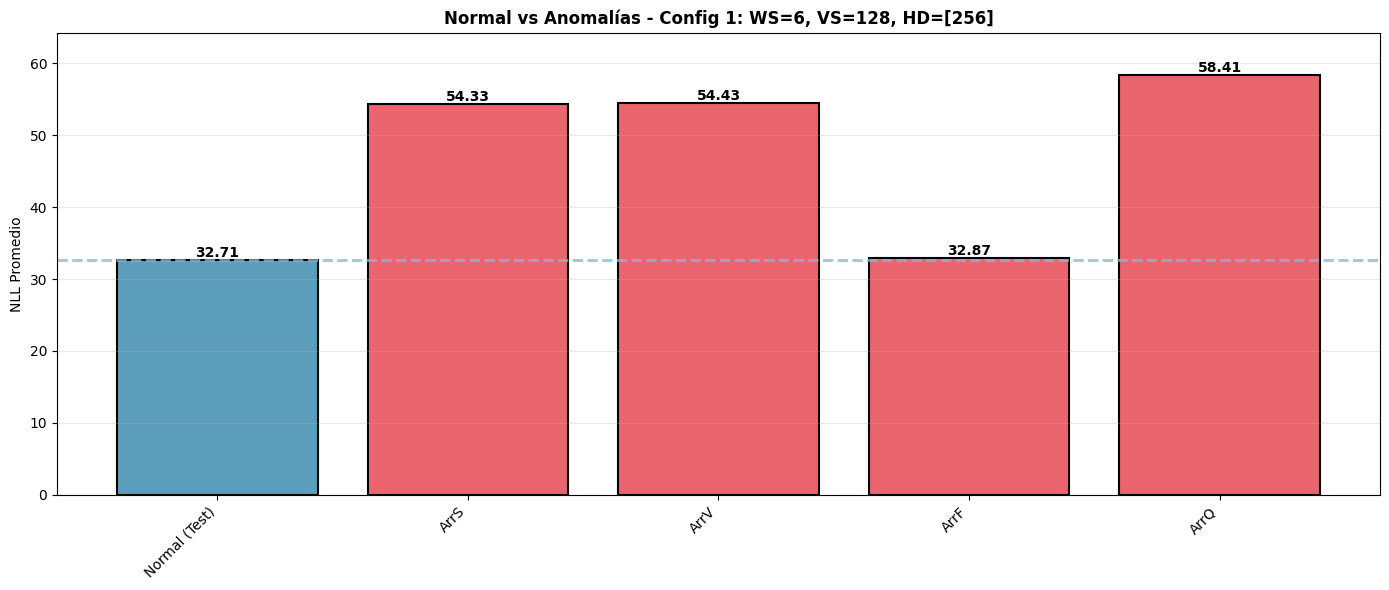


ANÁLISIS DE ANOMALÍAS - CONFIGURACIÓN 2/6
WINDOW_SIZE: 4, VOCAB_SIZE: 128, HIDDEN_DIMS: [256]

Calculando NLL para cada tipo de anomalía...
 - ArrS: 83.4068
 - ArrV: 88.3529
 - ArrF: 50.5317
 - ArrQ: 92.2947
 - ArrV: 88.3529
 - ArrF: 50.5317
 - ArrQ: 92.2947


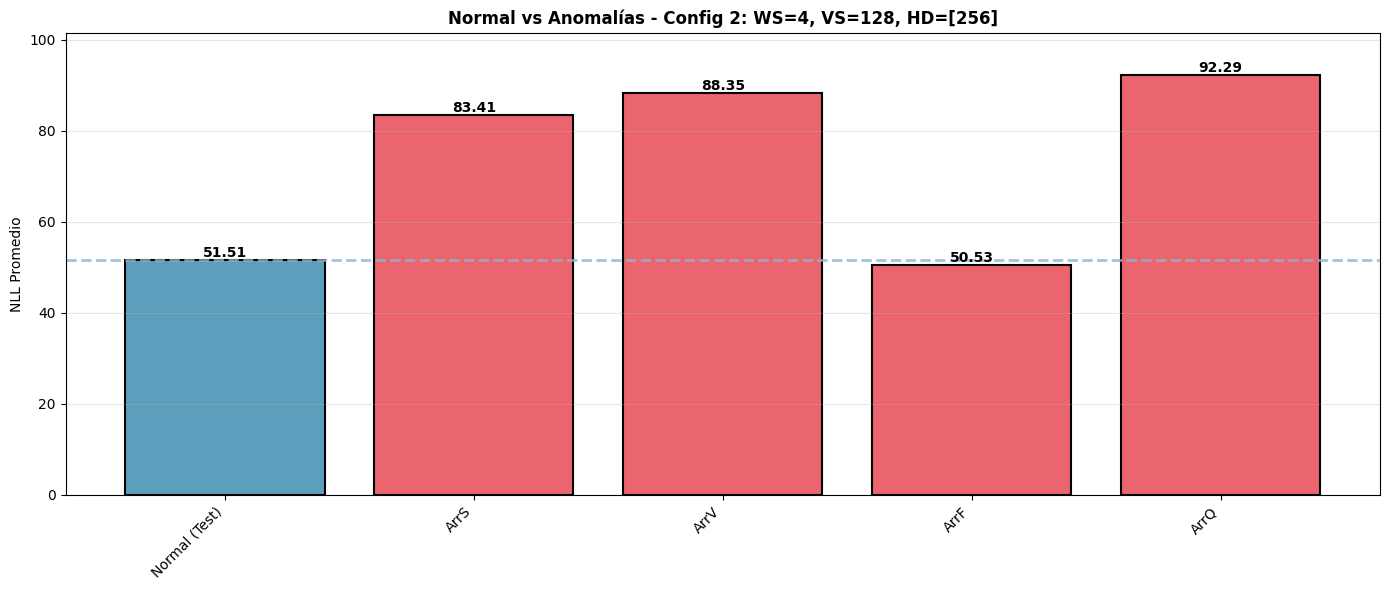


ANÁLISIS DE ANOMALÍAS - CONFIGURACIÓN 3/6
WINDOW_SIZE: 6, VOCAB_SIZE: 64, HIDDEN_DIMS: [256]

Calculando NLL para cada tipo de anomalía...
 - ArrS: 44.9510
 - ArrV: 46.5919
 - ArrF: 26.2936
 - ArrQ: 48.3458


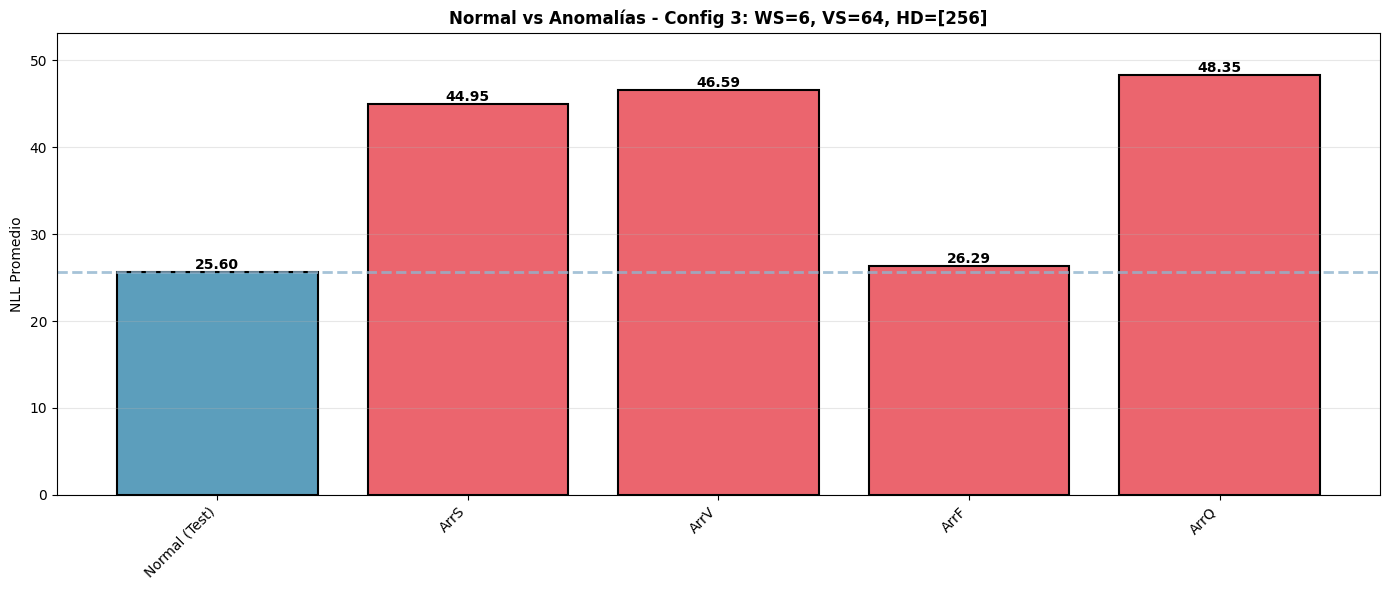


ANÁLISIS DE ANOMALÍAS - CONFIGURACIÓN 4/6
WINDOW_SIZE: 8, VOCAB_SIZE: 128, HIDDEN_DIMS: [512]

Calculando NLL para cada tipo de anomalía...
 - ArrS: 42.3536
 - ArrV: 44.1234
 - ArrF: 22.3876
 - ArrQ: 46.7547
 - ArrQ: 46.7547


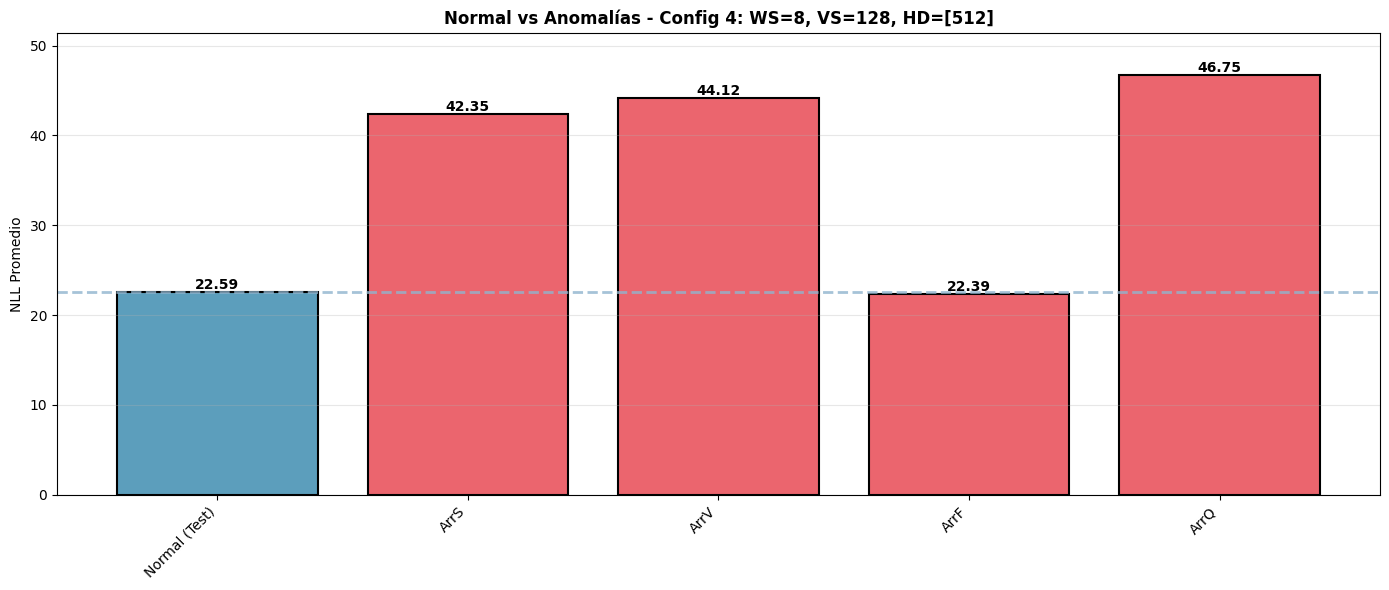


ANÁLISIS DE ANOMALÍAS - CONFIGURACIÓN 5/6
WINDOW_SIZE: 6, VOCAB_SIZE: 256, HIDDEN_DIMS: [128]

Calculando NLL para cada tipo de anomalía...
 - ArrS: 61.0857
 - ArrV: 61.2274
 - ArrF: 39.0335
 - ArrQ: 63.9511
 - ArrV: 61.2274
 - ArrF: 39.0335
 - ArrQ: 63.9511


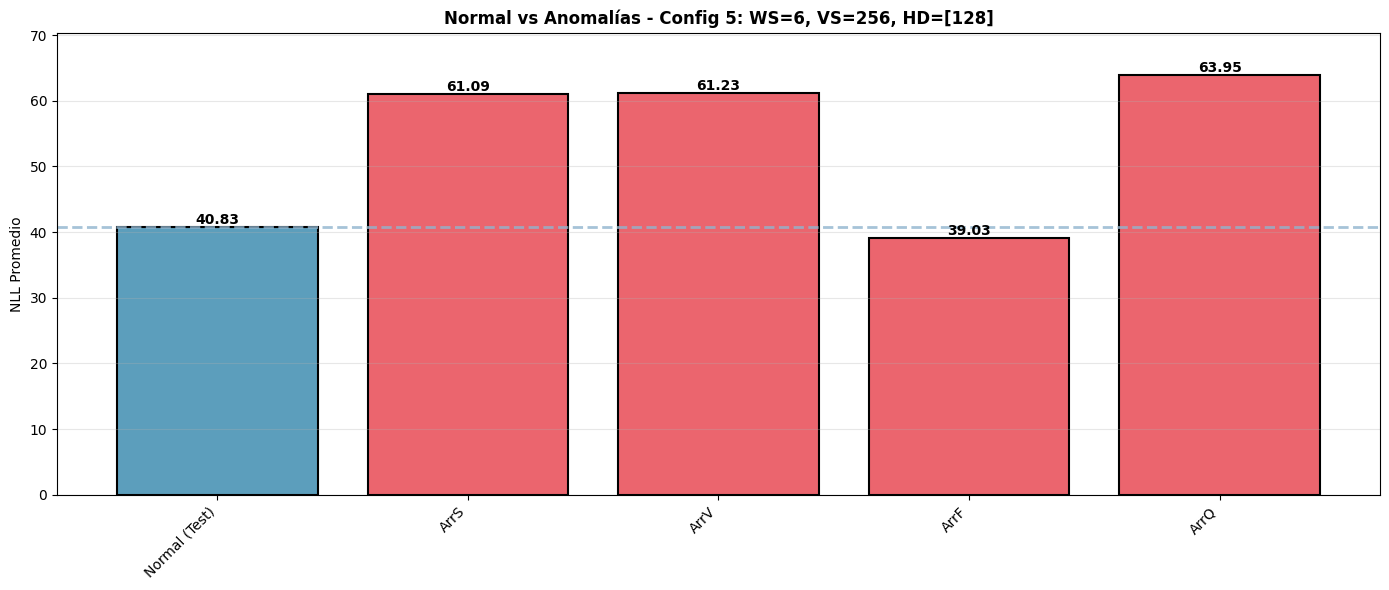


ANÁLISIS DE ANOMALÍAS - CONFIGURACIÓN 6/6
WINDOW_SIZE: 4, VOCAB_SIZE: 64, HIDDEN_DIMS: [512]

Calculando NLL para cada tipo de anomalía...
 - ArrS: 71.8760
 - ArrV: 79.5728
 - ArrF: 39.9845
 - ArrQ: 84.8381
 - ArrF: 39.9845
 - ArrQ: 84.8381


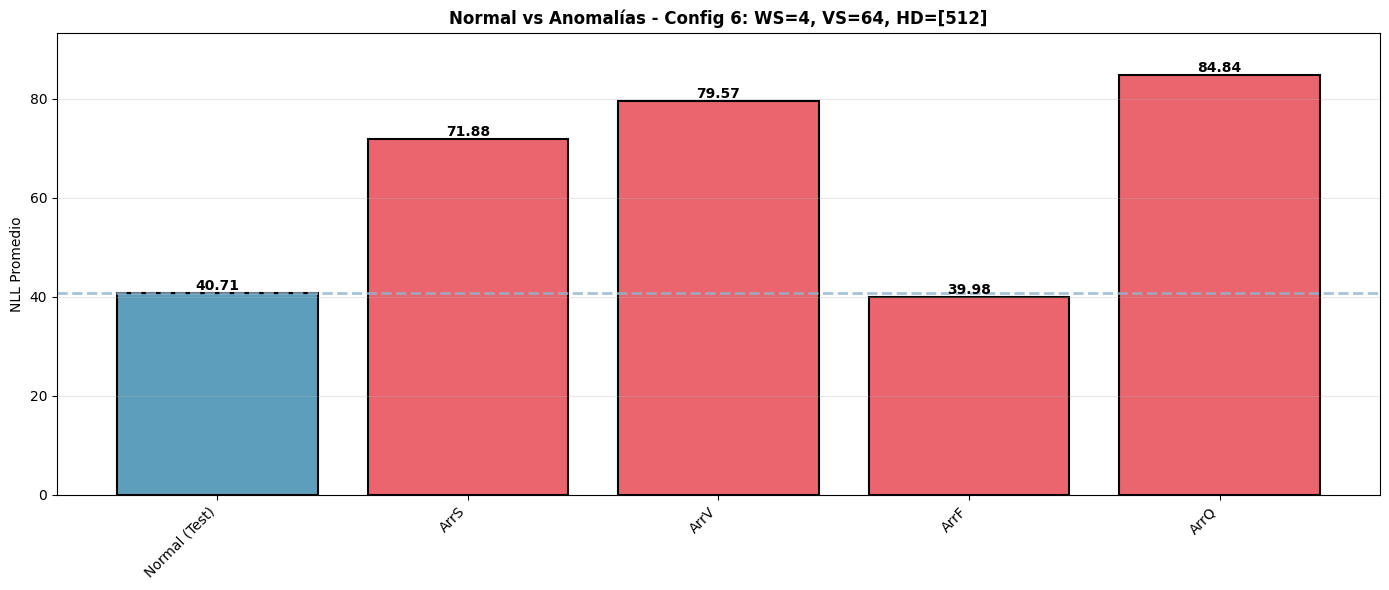


Análisis de anomalías completado para todas las configuraciones


In [10]:
# Detailed anomaly analysis for all configurations
class_map = {1: 'ArrS', 2: 'ArrV', 3: 'ArrF', 4: 'ArrQ'}

for idx, result in enumerate(results):
    print(f"\n{'='*80}")
    print(f"ANÁLISIS DE ANOMALÍAS - CONFIGURACIÓN {idx+1}/6")
    print(f"WINDOW_SIZE: {result['WINDOW_SIZE']}, VOCAB_SIZE: {result['VOCAB_SIZE']}, HIDDEN_DIMS: {result['HIDDEN_DIMS']}")
    print(f"{'='*80}\n")
    
    model = result['model']
    WINDOW_SIZE = result['WINDOW_SIZE']
    VOCAB_SIZE = result['VOCAB_SIZE']
    gmm = result['gmm']
    nll_test = result['nll_test']
    
    nll_results = {'Normal (Test)': nll_test}
    
    print("Calculando NLL para cada tipo de anomalía...")
    
    for class_id, class_name in class_map.items():
        X_class = X[y == class_name]
        
        if len(X_class) == 0:
            continue
            
        limit = min(len(X_class), 500)
        X_class_sample = X_class[:limit]
        
        padding = np.zeros((X_class_sample.shape[0], 2))
        X_class_padded = np.hstack((X_class_sample, padding))
        X_class_tokens = discretize_signals(X_class_padded, WINDOW_SIZE, gmm)
        ds_class = ECGTokenDataset(X_class_tokens, VOCAB_SIZE)
        nll_val = calculate_nll(model, ds_class)
        nll_results[class_name] = nll_val
        print(f" - {class_name}: {nll_val:.4f}")
    
    labels = list(nll_results.keys())
    values = list(nll_results.values())
    colors = ['#5c9ebc' if 'Normal' in label else '#eb656e' for label in labels]
    
    plt.figure(figsize=(14, 6))
    bars = plt.bar(labels, values, color=colors, edgecolor='black', linewidth=1.5)
    plt.axhline(y=nll_results['Normal (Test)'], color='#90b4ce', linestyle='--', linewidth=2, alpha=0.8)
    
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                 f'{height:.2f}',
                 ha='center', va='bottom', fontweight='bold')
    
    plt.title(f'Normal vs Anomalías - Config {idx+1}: WS={WINDOW_SIZE}, VS={VOCAB_SIZE}, HD={result["HIDDEN_DIMS"]}', 
              fontsize=12, fontweight='bold')
    plt.ylabel('NLL Promedio')
    plt.grid(axis='y', linestyle='-', alpha=0.3)
    plt.xticks(rotation=45, ha='right')
    plt.ylim(0, max(values) * 1.1)
    plt.tight_layout()
    plt.show()

print("\nAnálisis de anomalías completado para todas las configuraciones")